<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/GoingDeeper/05_Attention/Seq2seq%E1%84%8B%E1%85%AA_Attention%5B%E1%84%91%E1%85%B3%E1%84%85%E1%85%A9%E1%84%8C%E1%85%A6%E1%86%A8%E1%84%90%E1%85%B3%5D_Seq2seq%E1%84%8B%E1%85%B3%E1%84%85%E1%85%A9_%E1%84%87%E1%85%A5%E1%86%AB%E1%84%8B%E1%85%A7%E1%86%A8%E1%84%80%E1%85%B5_%E1%84%86%E1%85%A1%E1%86%AB%E1%84%83%E1%85%B3%E1%86%AF%E1%84%80%E1%85%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === Colab 호환 셋업 (자동 추가) ===
import torch as _t
_t._orig_load = getattr(_t, '_orig_load', _t.load)
def _compat_load(*a, **k):
    k.setdefault('weights_only', False)
    return _t._orig_load(*a, **k)
_t.load = _compat_load
try:
    import matplotlib; matplotlib.rcParams['axes.unicode_minus'] = False
except Exception: pass
print('[colab-compat] torch.load weights_only=False 패치 적용')


[colab-compat] torch.load weights_only=False 패치 적용


# 들어가며

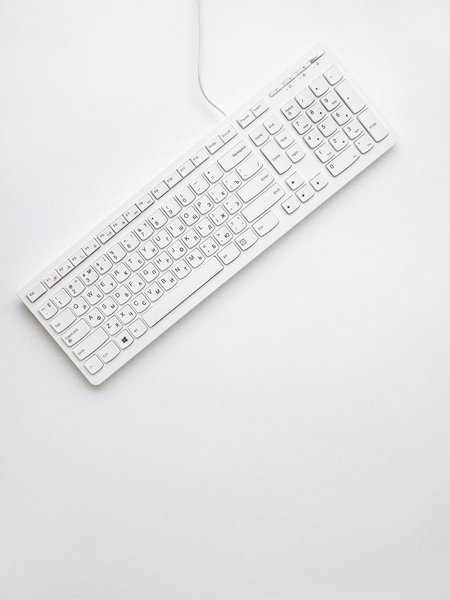

이전 시간에 멋진 **Sequence-to-Sequence** 구조를 배웠습니다. 두 개의 RNN 모듈을 Encoder-Decoder 구조로 결합하여 사용하는 Seq2seq은 그야말로 혁신이었습니다.

Seq2seq이 번역기에 최적화되어 있는 만큼, 이번 코스에선 **Seq2seq 기반 번역기를 직접 만들어보며** 그 구조를 이해해보도록 하겠습니다. 또한 Attention 기법을 추가하여 성능을 높여보기도 할 거고요!

실습에는 영어-스페인어 말뭉치를 사용하지만 직접 하실 프로젝트는 한국어-영어 말뭉치를 사용할 것입니다. 그럼 시작합시다!

**[아이스브레이킹] 지난 시간에 배운 Sequence-to-Sequence에 대해서 간단하게 생각해 볼까요?**

A. Sequence-to-Sequence 모델은 일련의 입력 시퀀스를 다른 일련의 출력 시퀀스로 변환하는 모델입니다.
이 모델은 대부분 자연어 처리에서 사용되며, 예를 들어 기계 번역, 챗봇, 요약, 질의응답 등의 작업에서 널리 사용됩니다.

## 학습 내용
---
2. 데이터 전처리

    필요한 데이터를 준비하고 전처리합니다.

3. 모델 설계

    Bahdanau Attention을 사용해서 코드 실습을 합니다.

4. 훈련하기 (1) Optimizer & Loss

    Encoder-Decoder 구조를 정의합니다.

5. 훈련하기 (2) train_step 구현하기

    Loss를 계산한 후 반환하는 함수를 학습합니다.

6. 훈련하기 (3) 훈련 시작하기

    학습을 진행하고 시각화합니다.

## 학습 목표
---
- 데이터를 필요에 맞게 전처리할 수 있다.
- Encoder-Decoder 구조를 이해할 수 있다.
- Encoder-Decoder 구조를 다른 사람에게 설명할 수 있다.

## 준비물
---
터미널을 열고 프로젝트를 위한 디렉토리를 생성해 주세요.

```
$ mkdir -p ~/aiffel/s2s_translation
```

실습에서는 한국어가 포함된 말뭉치를 사용하므로, 한국어를 잘 시각화하기 위한 준비가 필요합니다. 다만 *`matplotlib` 라이브러리의 기본 폰트는 한국어를 지원하지 않아요!* 올바른 Attention Map을 확인하기 위해 한국어를 지원하는 폰트로 변경해 주도록 합시다.

In [2]:
!apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 57 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (9,472 kB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122579 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as ticker
import logging

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


# 데이터 전처리

## 데이터 준비하기
---
먼저 프로젝트에 사용될 라이브러리를 `import` 하도록 합시다.

In [4]:
import os
import re
import urllib.request
import zipfile
import sentencepiece as spm
import pandas as pd

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)

2.11.0+cu128


데이터를 다운로드하는 데에는 `urllib.request.urlretrieve()` 함수를 사용할 겁니다. `urllib.request.urlretrieve()`함수는 URL로부터 데이터를 다운받고, `zip_ref.extractall()` 함수는 폴더 내 압축된 파일들을 찾아 해제까지 알아서 할 수 있는 똑똑한 함수랍니다! 아래 소스를 실행해 데이터를 다운로드받아주세요.

In [5]:
dataset_dir = os.path.join(os.path.expanduser("/content/datasets"), "spa-eng")
os.makedirs(dataset_dir, exist_ok=True)
zip_path = os.path.join(dataset_dir, "spa-eng.zip")

if not os.path.exists(zip_path):
    print("데이터 다운로드 중...")
    url = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("다운로드 완료!")

data_folder = os.path.join(dataset_dir, "spa-eng")
if not os.path.exists(data_folder):
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print("압축 해제 완료!")

path_to_file = os.path.join(data_folder, "spa.txt")

print("데이터셋 디렉토리:", os.listdir(dataset_dir))

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!
데이터셋 디렉토리: ['spa-eng', 'spa-eng.zip']


다운로드받은 데이터를 읽어온 후, 형태를 확인해보도록 하죠!

In [6]:
df = pd.read_csv(path_to_file, sep = "\t", names = ["eng", "spa"])
df.head()

,eng,spa
0,Go.,Ve.
1,Go.,Vete.
2,Go.,Vaya.
3,Go.,Váyase.
4,Hi.,Hola.


## 데이터 전처리: 정제하기
---
데이터는 `\t` 기호를 기준으로 영어와 스페인어가 병렬 쌍을 이루고 있습니다. 고로 `\t` **기호를 매개변수로** `split()` **함수를 호출**하면 손쉽게 소스 문장과 타겟 문장을 분리할 수 있겠죠! 추가로 위 예시의 네 번째 문장을 보면 `¡` 같은 요상한 기호가 포함되어 있곤 합니다. 이 같은 특수문자는 **불필요한 노이즈로 작용**할 수 있기 때문에 정**제 과정에서 삭제**하도록 하겠습니다.

> 사실 스페인에서는 역 물음표(¿)와 역 느낌표(¡)를 일반적으로 사용합니다. 문장이 물음표나 느낌표로 끝난다면 해당 문장 맨 앞에 역으로 된 기호를 붙여준다고 해요. 이해를 돕기 위해 이상한 기호 취급을 하였으니 양해를 바랍니다!

정제는 아래 소스를 실행함으로써 진행할 수 있습니다.

In [7]:
def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()

    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    # 스페인어 문자(á é í ó ú ü ñ)는 보존하고, 노이즈 취급하는 역물음표/역느낌표(¿ ¡)만 제거
    sentence = re.sub(r"[^a-záéíóúüñ?.!,]+", " ", sentence)

    sentence = sentence.strip()

    return sentence

print("슝~")

슝~


전처리 과정에서 문장의 시작 문자 `<start>`, 종료 문자 `<end>` 를 붙여주게 됩니다. 이 작업은 Encoder에 들어갈 입력 문장의 전처리에는 굳이 필요하지 않지만, Decoder의 입력 문장과 라벨로 사용할 출력 문장에는 꼭 필요하게 됩니다. 이전 렉처 노드에서 살펴보았듯, Decoder는 첫 입력으로 사용할 시작 토큰과 문장생성 종료를 알리는 끝 토큰이 반드시 필요하기 때문입니다.

원활한 학습을 위해 **데이터는 상위 3만 개만 사용**하도록 하겠습니다.

In [8]:
#df = df[:30000]

df["eng"] = df["eng"].apply(preprocess_sentence)
df["spa"] = df["spa"].apply(lambda x: preprocess_sentence(x))

df.head()

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,váyase .
4,hi .,hola .


## 데이터 전처리: 토큰화
---
`SentencePiece`를 사용하려면 텍스트 파일이 필요합니다. 먼저 `SentencePiece`를 활용해 Tokenizer를 생성하고 테이터를 변환하겠습니다. **변환된 텐서를 80%의 훈련 데이터와 20%의 검증 데이터로 분리하세요!** (Tokenizer의 단어 수는 자유롭게 진행하세요!)

In [10]:
df["eng"].to_csv("eng_corpus.txt", index=False, header=False, encoding="utf-8")
df["spa"].to_csv("spa_corpus.txt", index=False, header=False, encoding="utf-8")

print("파일 저장 완료: eng_corpus.txt, spa_corpus.txt")

파일 저장 완료: eng_corpus.txt, spa_corpus.txt


In [11]:
vocab_size = 3000
pad_id = 0
bos_id = 1
eos_id = 2
unk_id = 3

spm.SentencePieceTrainer.train(
    input = "eng_corpus.txt",
    model_prefix = "encoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

spm.SentencePieceTrainer.train(
    input = "spa_corpus.txt",
    model_prefix = "decoder_spm",
    vocab_size = vocab_size,
    pad_id = pad_id,
    bos_id = bos_id,
    eos_id = eos_id,
    unk_id = unk_id
)

True

In [12]:
encoder_tokenizer = spm.SentencePieceProcessor()
encoder_tokenizer.load("encoder_spm.model")

decoder_tokenizer = spm.SentencePieceProcessor()
decoder_tokenizer.load("decoder_spm.model")

True

SentencePiece는 디코딩 과정에서 START_TOKEN과 END_TOKEN을 자동으로 변환해줍니다.

In [13]:
df

,eng,spa
0,go .,ve .
1,go .,vete .
2,go .,vaya .
3,go .,váyase .
4,hi .,hola .
...,...,...
118959,there are four main causes of alcohol related ...,hay cuatro causas principales de muertes relac...
118960,there are mothers and fathers who will lie awa...,hay madres y padres que se quedan despiertos d...
118961,a carbon footprint is the amount of carbon dio...,una huella de carbono es la cantidad de contam...
118962,since there are usually multiple websites on a...,como suele haber varias páginas web sobre cual...


In [14]:
eng_sample = df["eng"][10000]
spa_sample = df["spa"][10000]
print(eng_sample)
print(spa_sample)

do you like fish ?
te gusta el pescado ?


문장을 인코딩한 뒤 START_TOKEN과 END_TOKEN을 붙여주겠습니다.

In [15]:
enc_token = encoder_tokenizer.encode(eng_sample)
enc_token = [encoder_tokenizer.bos_id()] + enc_token + [encoder_tokenizer.eos_id()]
enc_token

[1, 23, 8, 48, 612, 11, 2]

위 토큰을 디코딩하면 어떻게 될까요?

In [16]:
enc_decoding = encoder_tokenizer.decode(enc_token)
enc_decoding

'do you like fish ?'

이처럼 디코딩 과정에선 START_TOKEN과 END_TOKEN 부분을 제외하고 디코딩을 합니다.

START_TOKEN과 END_TOKEN은 데이터셋을 생성하는 과정에서 추가해주도록 하겠습니다. 일반적으로 Padding 작업은 `torch.nn.utils.rnn.pad_sequence`와 같은 라이브러리를 사용하지만 여기에서는 과정을 좀 더 풀어서 보여드리도록 하겠습니다.

In [17]:
class TranslationDataset(Dataset):
    def __init__(self, data, encoder_tokenizer, decoder_tokenizer, max_len):
        self.data = data
        self.encoder_tokenizer = encoder_tokenizer
        self.decoder_tokenizer = decoder_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['eng']
        trg_text = self.data.iloc[idx]['spa']

        src_ids = self.encoder_tokenizer.encode(src_text)
        trg_ids = self.decoder_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]

        # Decoder의 입력에는 START_TOKEN과 END_TOKEN을 추가해줍니다. 단, 최대 길이 제한을 적용시킵니다.
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 길이가 짧은 경우 PAD_TOKEN을 추가해줍니다.
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

In [18]:
train_ratio = 0.8  # 전체 길이의 80%
MAX_LEN = 30 # 임의의 값
BATCH_SIZE = 64

train_data = df.sample(frac=train_ratio, random_state=42)  # 전체의 80%를 훈련 데이터로
valid_data = df.drop(train_data.index)

train_data.reset_index(drop=True, inplace=True)
valid_data.reset_index(drop=True, inplace=True)

train_data = TranslationDataset(train_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)
validataion_data = TranslationDataset(valid_data, encoder_tokenizer, decoder_tokenizer, max_len=MAX_LEN)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validataion_data, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 30]) torch.Size([64, 30]) torch.Size([64, 30])


# 모델 설계
이제부터 아래 그림처럼 **각각 1개의 GRU을 갖는 Encoder-Decoder 구조**를 설계할 겁니다.

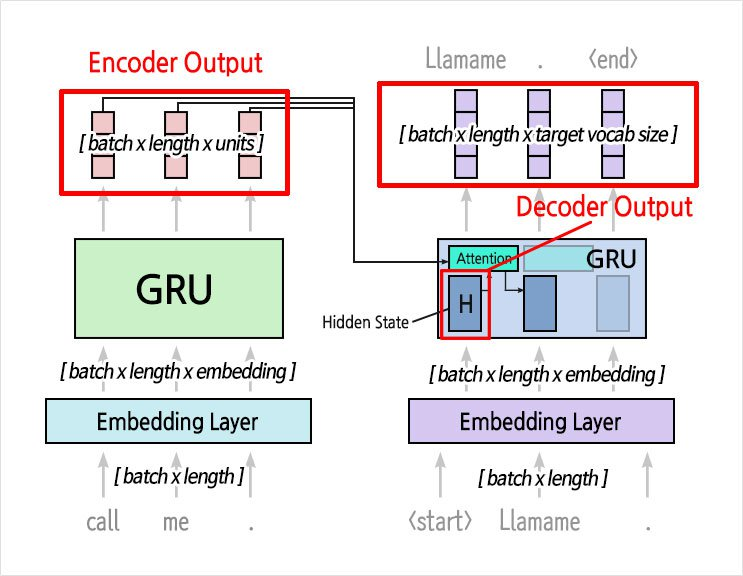

[GRU 구조]

Encoder는 **모든 Time-Step의 Hidden State를 출력**으로 갖고, Decoder는 **Encoder의 출력**과 Decoder의 **t-1 Step의 Hidden State로 Attention**을 계산하고, 그 컨텍스트 벡터를 현재 스텝의 출력(Hidden State)과 결합하여 **t Step의 예측**을 만들어 냅니다.

Decoder에서 t Step의 단어로 예측된 것을 실제 정답과 대조해 Loss를 구하고, 생성된 t Step의 Hidden State는 t+1 Step의 Hidden State를 만들기 위해 다시 Decoder에 전달됩니다.

여기서 '**t=1 일 때의 Hidden State는 어떻게 정의할 것인가?**' 가 궁금하실 수 있는데요, 일반적으로 Encoder의 Final State를 Hidden State로 사용합니다.

Attention은 Bahdanau을 사용할 예정이며, 이는 이전 렉처 노드에서 실습한 코드를 가져다가 쓰도록 할게요.

**Q. Bahdanau Attention을 사용할 예정인데 특징이 뭐였죠?**

<details>
<summary>💡예시답안 확인하기💡</summary>

입력 시퀀스의 각 위치마다 가중치를 학습하여 중요도를 결정합니다. \
즉, 입력 시퀀스의 다른 위치에 대한 주의도가 다를 수 있습니다. 이를 통해 모델이 입력 시퀀스의 특정 부분에 집중하거나 무시할 수 있습니다.
</details>

In [20]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

**위 그림과 동일한 구조를 갖는 `Encoder` 클래스와 `Decoder` 클래스를 설계하고, 아래 소스를 실행해 답안과 같은 결과를 얻으세요.**

In [21]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [22]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [23]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
            # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

input_dim = len(encoder_tokenizer)
output_dim = len(decoder_tokenizer)
emb_dim = 256
hid_dim = 512

In [25]:
encoder = Encoder(input_dim, emb_dim, hid_dim).to(device)
attention = BahdanauAttention(hid_dim).to(device)
decoder = Decoder(output_dim, emb_dim, hid_dim, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

In [26]:
print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)


코드를 실행하면 다음과 같은 형식의 결과가 나와야 합니다.

```bash
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(3000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=3000, bias=True)
  )
)
```

<details>
<summary>Encoder 예제 코드</summary>


```python
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden
```

</details>


<details>
<summary>Decoder 예제 코드</summary>

```python
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)

        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)
```

</details>

# 훈련하기 (1) Optimizer & Loss
지금까지는 Optimizer 안에 파라미터를 간편하게 입력했지만, Encoder-Decoder 구조의 경우 모델이 분리되어 파라미터를 각각 정의해줘야 합니다. 조금 불편하고 난감하게 다가올 수도 있지만 후에 더 멋진 연구를 하기 위한 발판이 되어 줄 테니 익숙해져 봅시다!

낯선 함수들이 지나치게 많이 등장할 수 있으니, 이번 코스에선 직접 구현을 하기보단 구현체를 먼저 보고 이해하는 방향으로 공부하도록 합시다!

## Optimizer & Loss
---
가장 큰 줄기를 먼저 보고, 점점 더 들어가 보는 방식으로 진행해볼게요. 첫 순서는 **Optimizer와 Loss**입니다!

In [27]:
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

print("슝~")

슝~


**Optimizer**는 모델이 학습할 때에 정답을 찾아가는 방법 정도로 설명할 수 있는데, 일반적으론 Adam 외의 것을 사용하지 않으니 후에 실력이 더 늘어나고 나서 공부하시는 것을 권장합니다! 우선은 다른 배워야 할 것들이 산더미니까요...😅

`nn.CrossEntropyLoss()` 함수는 **모델이 출력한 확률 분포**와 (One-hot이 아닌) **정수 인덱스 답안**을 비교해 Cross Entropy값을 구해줍니다. `nn.NLLLoss()`라면 `[ 0.1, 0.2, 0.7 ]` 과 One-hot 인코딩된 라벨 `[0, 0, 1]` 을 비교하여 점수를 채점하겠지만, `nn.CrossEntropyLoss()` 함수라면 `[ 0.1, 0.2, 0.7 ]` 과 정수 인덱스 답안 `2` 를 비교하여 점수를 채점하는 거죠.

**Q. 패딩(Padding) 과정을 진행하는 이유가 뭘까요?**

<details>
<summary>💡예시답안 확인하기💡</summary>

효율적인 배치 처리, 메모리 효율성 등이 있습니다.
</details>

만약 모델에게 `<PAD>` 토큰이 **패딩을 위한 토큰이라고 명시하지 않으면** 모델은 데이터의 굉장히 많은 부분이 `<PAD>` 로 이뤄져 있다고 생각하게 됩니다. 쉽게 말해 **유난히 같은 답이 많은 객관식 시험**이라고나 할까요...? 어떤 시험이 한 번호로만 찍어도 80점 이상을 받을 수 있다면 그 시험은 공부를 절대 하지 않겠죠! 모델은 심지어 10,000개의 정답이 넘게 있는 고난도의 문제를 풀고 있기 때문에 **패딩에 대한 처리**를 해주지 않으면 `<PAD>` **토큰만을 생성할 확률이 굉장히 높아집니다.**

이것은 종종 발생하는 문제라서 기억해두시면 좋아요. 이 문제를 방지하기 위해 `mask` 가 사용됩니다! `mask` 는 정답지에서 `<PAD>` 토큰을 찾아내어 그 부분에 대한 Loss는 구하지 않도록 하는 역할을 해주죠. `equal()` 함수에 정확히는 0 이 아닌 `<PAD>` 토큰의 인덱스를 전달하는 것이 맞지만 **대부분의 경우는 0으로 패딩되기 때문에 편의상 0을 전달**하여 처리하도록 하겠습니다.

# 훈련하기 (2) train_step 구현하기
`train_step()`은 학습에 필요한 것을 모두 가져가 **Loss를 계산한 후 반환하는 함수**입니다. 먼저 구성을 보시죠!

In [28]:
def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        # DataLoader는 (batch, seq_len) 배치를 주지만, 모델/Encoder/Decoder는 (seq_len, batch)를 기대합니다.
        # 전치하지 않으면 batch와 seq_len 축이 뒤바뀌어 (오류 없이) 잘못된 정렬로 학습됩니다.
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        optimizer.zero_grad()

        outputs,_ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

print("슝~")


슝~


코드를 좀 더 자세히 살펴봅시다.

`train_step()`의 학습 과정은 아래와 같습니다.

1. model.train()을 호출하여 모델을 학습 모드로 전환합니다.
2. optimizer.zero_grad()를 통해 이전 배치에서 계산된 기울기를 초기화합니다.
3. Encoder에 소스 문장을 전달해 **컨텍스트 벡터인 `enc_out` 을 생성**
4. **t=0일 때**, Decoder의 Hidden State는 **Encoder의 Final State로 정의**. `h_dec = enc_hidden`
Encoder 처리
5. `<start>` 문장과 enc_out, Hidden State를 기반으로 **다음 단어(t=1)를 예측**. `predictions`
6. 예측된 단어와 정답 간의 Loss를 구한 후, t=1의 **정답 단어를 다음 입력으로 사용** (예측 단어 사용X)
7. 반복!

코드를 한 줄 한 줄 살피면 이해가 어려운 라인은 없을 거예요.

# 훈련하기 (3) 훈련 시작하기
다음 순서는 본격적으로 **훈련을 시작하는 부분**입니다! (훈련 시간은 약 15분 정도 소요 됩니다.)

In [29]:
%%time

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}')

Epoch 1: 100%|██████████| 1488/1488 [00:37<00:00, 39.43it/s, loss=1.53]


Epoch 1/10, Train Loss: 2.6474


Epoch 2: 100%|██████████| 1488/1488 [00:36<00:00, 40.77it/s, loss=1.09]


Epoch 2/10, Train Loss: 1.4341


Epoch 3: 100%|██████████| 1488/1488 [00:36<00:00, 41.07it/s, loss=1.09]


...

Epoch 8/10, Train Loss: 0.3838


Epoch 9: 100%|██████████| 1488/1488 [00:36<00:00, 41.29it/s, loss=0.514]


Epoch 9/10, Train Loss: 0.3474


Epoch 10: 100%|██████████| 1488/1488 [00:36<00:00, 41.11it/s, loss=0.261]

Epoch 10/10, Train Loss: 0.3211
CPU times: user 6min 7s, sys: 1.21 s, total: 6min 8s
Wall time: 6min 5s


먼저 `tqdm`은 훈련의 진행 과정을 한눈에 볼 수 있게 해주는 라이브러리입니다. 사용법은 위 예제만 봐도 이해가 갈 정도로 정말 간단하니 웬만하면 활용하시는 것을 추천해 드려요! `# tqdm`이 붙은 라인은 모두 출력에 관련된 내용이니 설명을 생략하겠습니다. 궁금하신 분들은 아래 github을 참고하시길 바라요!

- [tqdm/tqdm](https://github.com/tqdm/tqdm)

먼저 `EPOCHS = 10` 만큼 반복하는 루프에 진입한 후, 각 배치의 시작 인덱스를 `idx_list` 배열에 저장합니다. 그리고 모델이 학습을 원활하게 할 수 있도록 데이터를 섞어줘야 하는데요, **인덱스를 섞어서 처리**할 겁니다. 순차적인 인덱스로 데이터를 불러오는 게 아닌 랜덤한 인덱스로 데이터를 불러오는 것은 데이터를 섞는 것과 동일한 효과를 가져오겠죠!

그 후에 각 미니배치를 `train_step()` 함수에서 학습합니다. `train_step()`은 학습에 필요한 것은 모두 가져가 **Loss를 계산한 후 반환하는 함수**였죠!

이번 기회에 Encoder-Decoder 구조의 학습 방법을 마스터하세요! `optimizer`와 `loss`, `train_step()`까지 정의한 후 훈련을 시작하면 아래와 같은 결과를 확인할 수 있습니다.


```
Epoch 1: 100%|██████████| 375/375 [02:38<00:00,  2.37it/s, loss=1.54]
Epoch 1/10, Train Loss: 1.7942
Epoch 2: 100%|██████████| 375/375 [02:46<00:00,  2.25it/s, loss=1.4]
Epoch 2/10, Train Loss: 1.4438

...

Epoch 10: 100%|██████████| 375/375 [02:49<00:00,  2.21it/s, loss=1.27]
Epoch 10/10, Train Loss: 1.2092

```


## 실습하기
---
이제 직접 실습해 볼까요?

**Step 1에서 분리한 Validation Set을 사용하는 `eval_step()` 함수를 정의하세요! 그리고 train_step() 을 마친 후, 곧이어 `eval_step()` 을 진행하도록 소스를 수정하세요! 결과는 아래와 같은 형태가 되어야 합니다.**

(주의! Evaluation 중에는 모델이 학습을 해서는 안 됩니다!)


```bash
Epoch  1: 100%|██████████| 375/375 [00:50<00:00,  7.45it/s, Loss 1.7839]
Test Epoch  1: 100%|██████████| 94/94 [00:09<00:00,  9.75it/s, Test Loss 1.4220]
Epoch  2: 100%|██████████| 375/375 [00:31<00:00, 11.74it/s, Loss 1.2333]
Test Epoch  2: 100%|██████████| 94/94 [00:02<00:00, 46.58it/s, Test Loss 1.1305]
Epoch  3: 100%|██████████| 375/375 [00:31<00:00, 11.77it/s, Loss 0.9801]
Test Epoch  3: 100%|██████████| 94/94 [00:01<00:00, 48.42it/s, Test Loss 0.9771]
Epoch  4: 100%|██████████| 375/375 [00:31<00:00, 11.74it/s, Loss 0.7998]
Test Epoch  4: 100%|██████████| 94/94 [00:02<00:00, 46.70it/s, Test Loss 0.8701]
Epoch  5: 100%|██████████| 375/375 [00:31<00:00, 11.81it/s, Loss 0.6553]
Test Epoch  5: 100%|██████████| 94/94 [00:01<00:00, 47.60it/s, Test Loss 0.7903]
...
```



In [38]:
def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    # 평가 시에는 기울기 계산을 하지 않도록 설정합니다.
    with torch.no_grad():
        for src, trg_input, trg_label in data_loader:
            src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

            # 학습과 동일하게 (seq_len, batch)로 전치
            src = src.transpose(0, 1)
            trg_input = trg_input.transpose(0, 1)
            trg_label = trg_label.transpose(0, 1)

            outputs, _ = model(src, trg_input)

            # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            loss = criterion(outputs, trg_label)

            total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")

슝~


In [31]:
%%time

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

Epoch 1: 100%|██████████| 1488/1488 [00:36<00:00, 41.16it/s, loss=0.733]


Epoch 1/20, Train Loss: 0.3059, Validation Loss: 1.8930


Epoch 2: 100%|██████████| 1488/1488 [00:36<00:00, 41.14it/s, loss=0.0889]


Epoch 2/20, Train Loss: 0.2922, Validation Loss: 1.9495


Epoch 3: 100%|██████████| 1488/1488 [00:36<00:00, 41.23it/s, loss=0.356]


...

Epoch 18/20, Train Loss: 0.2893, Validation Loss: 2.4357


Epoch 19: 100%|██████████| 1488/1488 [00:36<00:00, 40.92it/s, loss=0.165]


Epoch 19/20, Train Loss: 0.2918, Validation Loss: 2.4469


Epoch 20: 100%|██████████| 1488/1488 [00:36<00:00, 41.06it/s, loss=0.371]


Epoch 20/20, Train Loss: 0.2988, Validation Loss: 2.4745
CPU times: user 13min 27s, sys: 2.26 s, total: 13min 29s
Wall time: 13min 22s


훈련이 완료된 모델은 아래 소스를 실행해 번역 성능을 평가할 수 있어요. Attention Map을 시각화하는 것은 보너스!

In [32]:
def evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30, eos_id=2):
    model.eval()

    sentence = preprocess_sentence(sentence)
    src_ids = encoder_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()

    # SentencePiece는 EOS를 빈 문자열로 디코딩하므로 "<end>" 문자열 비교로는 잘리지 않습니다.
    # 토큰 id 기준(eos_id)으로 잘라줍니다.
    if eos_id in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(eos_id)]

    # Attention 시각화의 y축 라벨로 쓰기 위해 토큰(subword) 단위 조각으로 반환
    result = [decoder_tokenizer.id_to_piece(i) for i in pred_ids]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

In [54]:
import matplotlib.font_manager as fm

# 한글 폰트 명시적 설정
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
fontprop = fm.FontProperties(fname=fontpath, size=14)

def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.matshow(attention, cmap='viridis')

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontproperties=fontprop, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontproperties=fontprop)

    plt.show()

In [34]:
def translate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len=30):
    result, sentence, attention = evaluate(sentence, model, encoder_tokenizer, decoder_tokenizer, max_len)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(sentence.split())]

    plot_attention(attention, sentence.split(), result)

Input: the most powerful man all over the world .
Predicted translation: ['▁todo', '▁el', '▁hombre', '▁más', '▁rico', '▁todo', '▁lo', '▁que', '▁se', '▁preocupa', 'ba', '▁todo', '▁el', '▁mundo', '▁.']


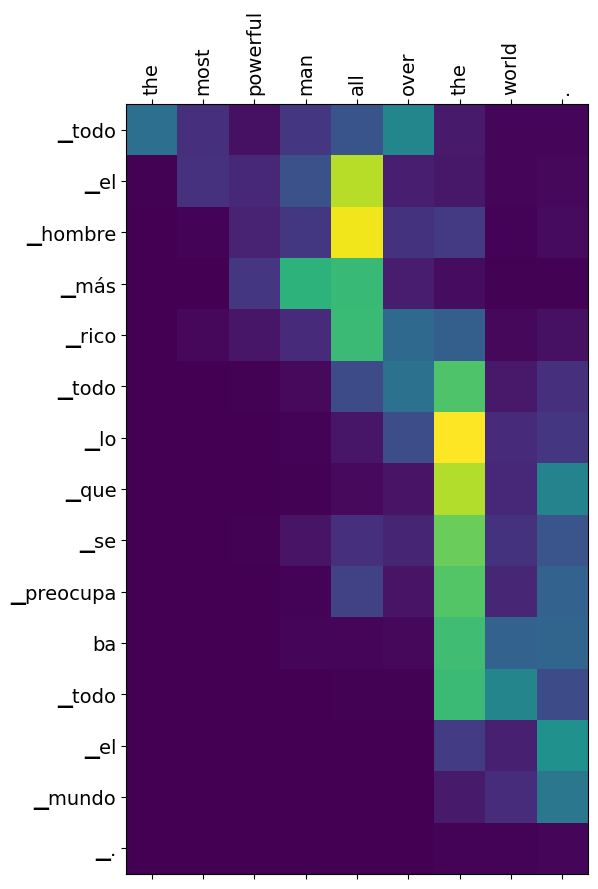

In [35]:
translate("The most powerful man all over the world.", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: may i help you ?
Predicted translation: ['▁puedo', '▁ayudarte', '▁?']


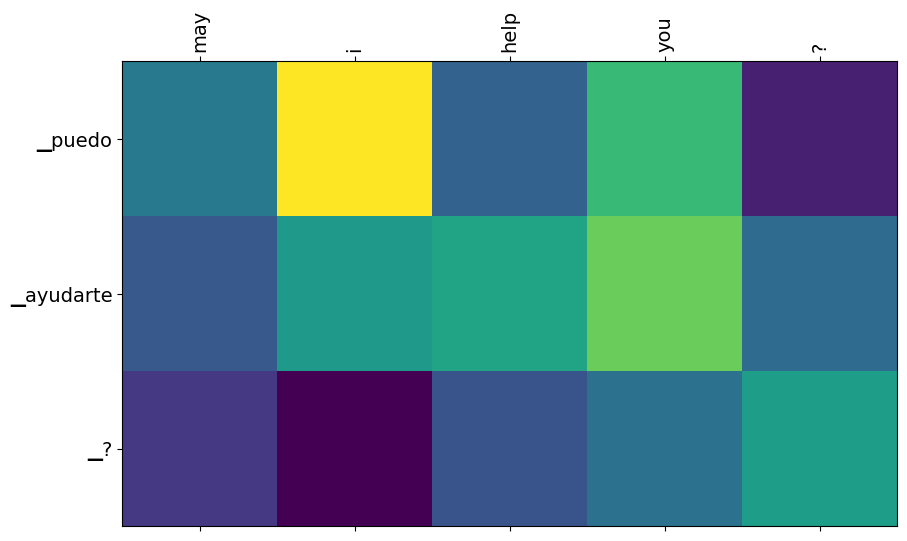

In [36]:
translate("May I help you?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

Input: can i have some coffee ?
Predicted translation: ['▁puedo', '▁hacer', '▁algo', '▁de', '▁café', '▁?']


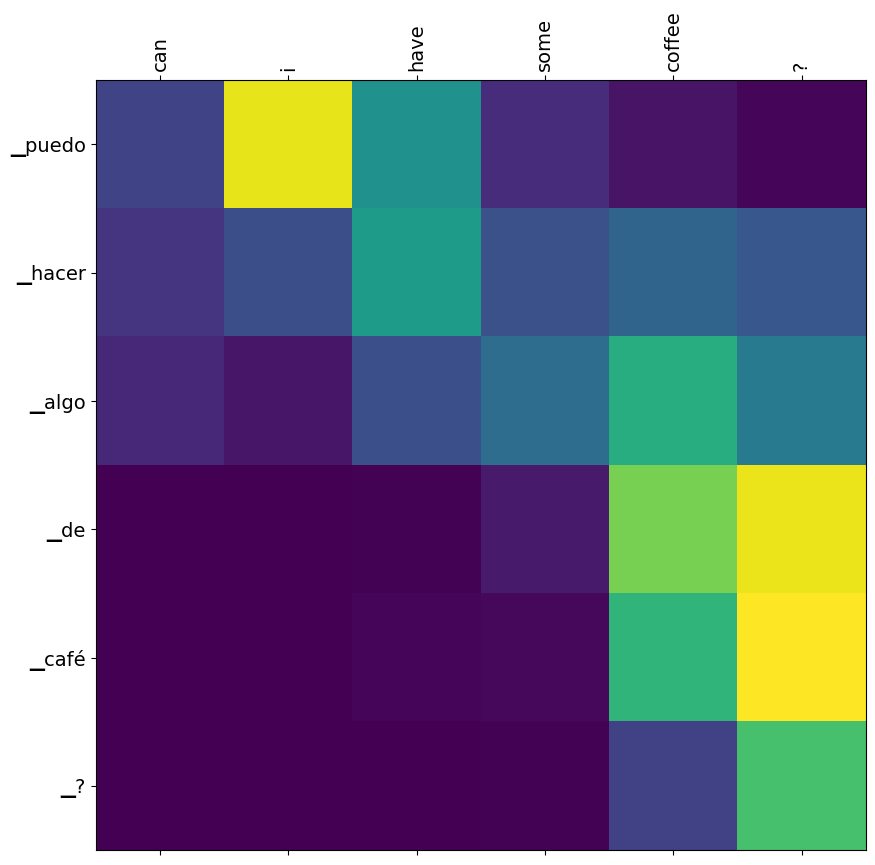

In [37]:
# 실행 예제
translate("Can I have some coffee?", model, encoder_tokenizer, decoder_tokenizer, max_len=30)

### 모델 번역 결과 vs 실제 정답 비교해보기

In [39]:
import random

# 검증 데이터셋에서 무작위로 5개의 샘플을 추출합니다.
samples = valid_data.sample(5)

print("=== 번역 결과 vs 실제 문장 비교 ===\n")

for idx, row in samples.iterrows():
    eng_text = row['eng']
    spa_text = row['spa']

    # 모델을 통해 번역 예측 (evaluate 함수 사용)
    result, _, _ = evaluate(eng_text, model, encoder_tokenizer, decoder_tokenizer, max_len=30)

    # SentencePiece의 띄어쓰기 특수기호( )를 일반 공백으로 변환하여 문장 복원
    pred_sentence = "".join(result).replace(' ', ' ').strip()

    print(f"🗣️ 영어 (Input)    : {eng_text}")
    print(f"✅ 실제 (Actual)   : {spa_text}")
    print(f"🤖 예측 (Predicted): {pred_sentence}")
    print("-" * 60)

=== 번역 결과 vs 실제 문장 비교 ===

🗣️ 영어 (Input)    : i saw her clean the room .
✅ 실제 (Actual)   : la vi limpiar la habitación .
🤖 예측 (Predicted): ▁la▁vi▁entrar▁a▁la▁pieza▁.
------------------------------------------------------------
🗣️ 영어 (Input)    : there were too many people at the concert .
✅ 실제 (Actual)   : había demasiada gente en el concierto .
🤖 예측 (Predicted): ▁se▁mesion▁demasiado▁al▁concierto▁.
------------------------------------------------------------
🗣️ 영어 (Input)    : take off your shoes .
✅ 실제 (Actual)   : quítese los zapatos .
🤖 예측 (Predicted): ▁quítese▁los▁zapatos▁.
------------------------------------------------------------
🗣️ 영어 (Input)    : i often went to the movies with my father .
✅ 실제 (Actual)   : yo iba a menudo a ver películas con mi padre .
🤖 예측 (Predicted): ▁a▁menudo▁me▁fui▁a▁menudo▁al▁cine▁con▁mi▁padre▁.
------------------------------------------------------------
🗣️ 영어 (Input)    : i know someone who speaks french well .
✅ 실제 (Actual)   : conozco a alguien que

아래와 같은 맵이 나오면 성공입니다.

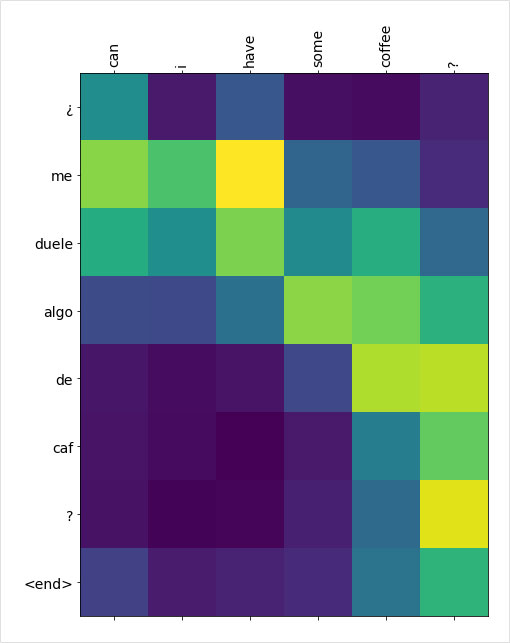

<details><summary>eval_step 예시 코드</summary>


```python
# Define eval_step

def eval_step(model, data_loader, optimizer, criterion):
    model.eval()
    total_loss = 0

    for src, trg_input, trg_label in data_loader:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        # 학습과 동일하게 (seq_len, batch)로 전치
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        outputs, _ = model(src, trg_input)

        # (trg_len, batch_size, output_dim)을 (batch_size * trg_len, output_dim)으로 변환
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)

        total_loss += loss.item()

    return total_loss / len(data_loader)

print("슝~")


# Training Process

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    valid_loss = eval_step(model, validation_loader, optimizer, criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')
```
</details>

---
# [프로젝트] 한국어-영어 번역기 만들기

지금부터는 루브릭 평가 기준을 만족하기 위한 **한국어-영어 번역기 프로젝트**를 진행합니다. 제공된 뉴스 병렬 말뭉치 데이터를 다운로드하고 전처리해보겠습니다.

In [40]:
import os
import urllib.request
import tarfile
import pandas as pd

# 다운로드 경로 설정
project_dir = "/content/ko-en-project"
os.makedirs(project_dir, exist_ok=True)
tar_path = os.path.join(project_dir, "korean-english-park.train.tar.gz")

# 1. 데이터 다운로드
url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")
else:
    print("이미 데이터가 존재합니다.")

# 2. 압축 해제
print("압축 해제 중...")
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=project_dir)
print("압축 해제 완료!")

# 3. 데이터 로드
ko_path = os.path.join(project_dir, "korean-english-park.train.ko")
en_path = os.path.join(project_dir, "korean-english-park.train.en")

with open(ko_path, "r", encoding="utf-8") as f:
    ko_data = f.read().splitlines()

with open(en_path, "r", encoding="utf-8") as f:
    en_data = f.read().splitlines()

# 데이터프레임으로 변환
project_df = pd.DataFrame({"ko": ko_data, "en": en_data})

print(f"\n총 데이터 개수: {len(project_df)}")
display(project_df.head())

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!

총 데이터 개수: 94123


/tmp/ipykernel_2433/1567787325.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=project_dir)


,ko,en
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


데이터가 잘 불러와졌나요?
이제 이 데이터에서 **중복된 문장을 제거**하고, 한글 전처리를 위해 **KoNLPy(Mecab) 등을 설치하여 형태소 분석 및 정제**를 진행해야 합니다.

위 코드를 실행해 보신 후 말씀해 주시면, 이어서 데이터 정제(Cleaning) 및 형태소 분석 코드를 제공해 드리겠습니다!

In [43]:
# 1. KoNLPy 및 Mecab 설치 (설치 완료 후 다음 셀을 실행하세요)
!pip install konlpy
!sudo apt-get install -y curl git
!bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh)
!pip install mecab-python3

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
curl is already the newest version (7.81.0-1ubuntu1.26).
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.
mecab-ko is already installed
mecab-ko-dic is already installed
<string>:1: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
Install mecab-python
/tmp /content
/content
Processing /tmp/mecab-python-0.996
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package menti

In [45]:
import re
from konlpy.tag import Okt

# 중복 문장 제거
print(f"중복 제거 전 데이터 개수: {len(project_df)}")
project_df.drop_duplicates(inplace=True)
project_df.dropna(inplace=True)
print(f"중복 제거 후 데이터 개수: {len(project_df)}")

# 실습과 동일하게 빠른 학습을 위해 3만 개만 샘플링
project_df = project_df.sample(30000, random_state=42).reset_index(drop=True)

# Mecab 대신 별도 설치 없이 안정적인 Okt 사용
okt = Okt()

# 한국어 전처리 함수
def preprocess_korean(sentence):
    # 1. 구두점 분리
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    # 2. 여러 공백을 하나의 공백으로
    sentence = re.sub(r'[" "]+', " ", sentence)
    # 3. 한글, 영문, 숫자, 지정된 구두점 외의 문자는 공백으로 변환
    sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    sentence = sentence.strip()
    # 4. Okt를 사용한 형태소 분리
    sentence = " ".join(okt.morphs(sentence))
    return sentence

# 영어 전처리 함수 (기존과 유사하지만 스페인어 대신 영어 알파벳만 남김)
def preprocess_english(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return sentence

print("\n전처리 진행 중... (시간이 조금 걸릴 수 있습니다)")
project_df['ko'] = project_df['ko'].apply(preprocess_korean)
project_df['en'] = project_df['en'].apply(preprocess_english)
print("전처리 완료!")

display(project_df.head())

중복 제거 전 데이터 개수: 30000
중복 제거 후 데이터 개수: 30000

전처리 진행 중... (시간이 조금 걸릴 수 있습니다)
전처리 완료!


,ko,en
0,"이 에 반해 미국 학생 들 은 읽기 18 위 , 과학 22 위 , 수학 28 위 ,...","in contrast , u . s . students took th place i..."
1,에드워즈 는 20일 네바다주 에서 발 로 엉덩이 를 차인 느낌 이 라며 넘어졌을 때...,south carolina also is shaping up to be the la...
2,허블 담당자 들 은 B 면 백업 장치 에 스위치 가 작동 하지 않더라도 디자인 팀 ...,even if the switch over to the side b backup u...
3,"예 를 들어 , 상업 적 폐기물 은 생산 부품 비 로서 원가 계산 이 되어야만 한다 .","commercial waste , for example , has to be cos..."
4,이 조건 에 맞으면 회원 들 은 한 달 9달러 95 센트 약 9500원 로 멋진 상...,"once they are in , they are permitted to e mai..."


위 과정이 끝났다면, 데이터가 깔끔하게 형태소 단위로 잘 쪼개진 것을 확인하실 수 있을 거예요.
확인하셨다면 이어서 **토큰화(SentencePiece) 및 데이터셋/데이터로더 생성 단계**를 진행할 테니 말씀해 주세요!

In [46]:
import sentencepiece as spm

# 1. 텍스트 파일로 저장 (SentencePiece 학습용)
project_df["ko"].to_csv("ko_corpus.txt", index=False, header=False, encoding="utf-8")
project_df["en"].to_csv("en_corpus.txt", index=False, header=False, encoding="utf-8")

# 2. SentencePiece 모델 학습
vocab_size = 5000
pad_id, bos_id, eos_id, unk_id = 0, 1, 2, 3

print("한국어 SentencePiece 모델 학습 중...")
spm.SentencePieceTrainer.train(
    input="ko_corpus.txt",
    model_prefix="ko_spm",
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id
)

print("영어 SentencePiece 모델 학습 중...")
spm.SentencePieceTrainer.train(
    input="en_corpus.txt",
    model_prefix="en_spm",
    vocab_size=vocab_size,
    pad_id=pad_id,
    bos_id=bos_id,
    eos_id=eos_id,
    unk_id=unk_id
)

# 3. 토크나이저 로드
ko_tokenizer = spm.SentencePieceProcessor()
ko_tokenizer.load("ko_spm.model")

en_tokenizer = spm.SentencePieceProcessor()
en_tokenizer.load("en_spm.model")

print("SentencePiece 학습 및 로드 완료!")

한국어 SentencePiece 모델 학습 중...
영어 SentencePiece 모델 학습 중...
SentencePiece 학습 및 로드 완료!


In [47]:
import torch
from torch.utils.data import DataLoader, Dataset

# 4. 한국어-영어 데이터셋 클래스 정의
class KoEnTranslationDataset(Dataset):
    def __init__(self, data, src_tokenizer, trg_tokenizer, max_len):
        self.data = data
        self.src_tokenizer = src_tokenizer
        self.trg_tokenizer = trg_tokenizer
        self.max_len = max_len
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_text = self.data.iloc[idx]['ko']
        trg_text = self.data.iloc[idx]['en']

        src_ids = self.src_tokenizer.encode(src_text)
        trg_ids = self.trg_tokenizer.encode(trg_text)

        src_ids = src_ids[:self.max_len]
        trg_input = [self.bos_id] + trg_ids[:self.max_len - 2] + [self.eos_id]
        trg_label = trg_ids[:self.max_len - 1] + [self.eos_id]

        # 패딩 추가
        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)

# 5. 하이퍼파라미터 설정 및 DataLoader 생성
MAX_LEN = 40
BATCH_SIZE = 64
train_ratio = 0.8

# Train / Validation 분리
ko_en_train_data = project_df.sample(frac=train_ratio, random_state=42)
ko_en_valid_data = project_df.drop(ko_en_train_data.index)

ko_en_train_data.reset_index(drop=True, inplace=True)
ko_en_valid_data.reset_index(drop=True, inplace=True)

# Dataset 인스턴스화
ko_en_train_dataset = KoEnTranslationDataset(ko_en_train_data, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
ko_en_valid_dataset = KoEnTranslationDataset(ko_en_valid_data, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)

# DataLoader 인스턴스화
ko_en_train_loader = DataLoader(ko_en_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
ko_en_valid_loader = DataLoader(ko_en_valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"훈련 데이터 개수: {len(ko_en_train_dataset)}")
print(f"검증 데이터 개수: {len(ko_en_valid_dataset)}")
print("DataLoader 준비 완료!")

훈련 데이터 개수: 24000
검증 데이터 개수: 6000
DataLoader 준비 완료!


In [48]:
# 6. 한국어-영어 번역 모델 초기화
ko_vocab_size = len(ko_tokenizer)
en_vocab_size = len(en_tokenizer)
emb_dim = 256
hid_dim = 512

# 기존에 정의한 클래스들을 사용하여 새로운 모델 인스턴스 생성
ko_en_encoder = Encoder(ko_vocab_size, emb_dim, hid_dim).to(device)
ko_en_attention = BahdanauAttention(hid_dim).to(device)
ko_en_decoder = Decoder(en_vocab_size, emb_dim, hid_dim, ko_en_attention).to(device)
ko_en_model = Seq2SeqAttention(ko_en_encoder, ko_en_decoder, device).to(device)

print("한국어-영어 번역 모델 준비 완료!")
print(ko_en_model)

한국어-영어 번역 모델 준비 완료!
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(5000, 256)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(5000, 256)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=5000, bias=True)
  )
)


In [56]:
import torch.optim as optim
import torch.nn as nn

# 7. Optimizer 및 Loss 설정
ko_en_optimizer = optim.Adam(ko_en_model.parameters(), lr=1e-3)
# 패딩 토큰(pad_id=0)은 Loss 계산에서 제외
ko_en_criterion = nn.CrossEntropyLoss(ignore_index=0)

# 8. 모델 학습 시작
EPOCHS = 20 # 20 Epoch로 늘려 학습 진행

print("한국어-영어 번역 모델 학습을 시작합니다! (시간이 다소 소요됩니다)")

for epoch in range(EPOCHS):
    train_loss = train_step(ko_en_model, ko_en_train_loader, ko_en_optimizer, ko_en_criterion, epoch)
    valid_loss = eval_step(ko_en_model, ko_en_valid_loader, ko_en_optimizer, ko_en_criterion)
    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

한국어-영어 번역 모델 학습을 시작합니다! (시간이 다소 소요됩니다)


Epoch 1: 100%|██████████| 375/375 [00:12<00:00, 29.20it/s, loss=1.16]


Epoch 1/20, Train Loss: 1.0877, Validation Loss: 5.5519


Epoch 2: 100%|██████████| 375/375 [00:12<00:00, 29.10it/s, loss=0.984]


Epoch 2/20, Train Loss: 0.8670, Validation Loss: 5.8032


...

Epoch 18/20, Train Loss: 0.2283, Validation Loss: 8.3226


Epoch 19: 100%|██████████| 375/375 [00:12<00:00, 29.31it/s, loss=0.262]


Epoch 19/20, Train Loss: 0.2225, Validation Loss: 8.4306


Epoch 20: 100%|██████████| 375/375 [00:12<00:00, 29.37it/s, loss=0.279]


Epoch 20/20, Train Loss: 0.2174, Validation Loss: 8.5469


In [52]:
# 9. 한국어-영어 전용 평가 및 시각화 함수 정의
def ko_en_evaluate(sentence, model, src_tokenizer, trg_tokenizer, max_len=40, eos_id=2):
    model.eval()

    # 한국어 전처리 적용
    sentence = preprocess_korean(sentence)
    src_ids = src_tokenizer.encode(sentence)
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))  # 패딩 추가
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()

    if eos_id in pred_ids:
        pred_ids = pred_ids[:pred_ids.index(eos_id)]

    result = [trg_tokenizer.id_to_piece(i) for i in pred_ids]

    return result, sentence, attentions.squeeze(1).cpu().numpy()

def ko_en_translate(sentence, model, src_tokenizer, trg_tokenizer, max_len=40):
    result, processed_sentence, attention = ko_en_evaluate(sentence, model, src_tokenizer, trg_tokenizer, max_len)

    print('Input:', sentence)
    print('Predicted translation:', result)

    # Attention 크기 조정 (trg_len, src_len)
    attention = attention[:len(result), :len(processed_sentence.split())]

    # 기존에 정의된 plot_attention 함수 사용
    plot_attention(attention, processed_sentence.split(), result)

print("평가 함수 정의 완료!")

평가 함수 정의 완료!


=== 한국어-영어 번역 및 Attention Map 테스트 ===

Input: 오바마는 미국 대통령이다.
Predicted translation: ['▁obama', '▁is', '▁the', '▁first', '▁african', '▁american', '▁president', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


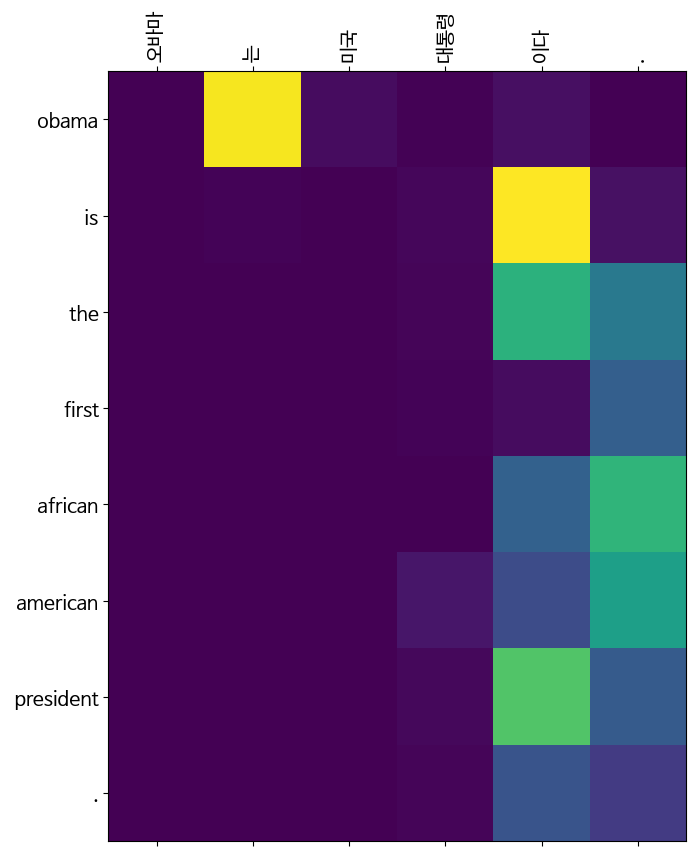

--------------------------------------------------
Input: 시민들은 도시 속에 산다.
Predicted translation: ['▁they', '▁write', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


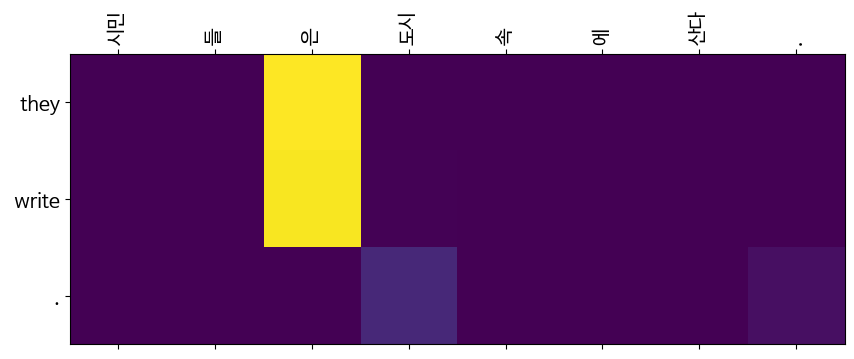

--------------------------------------------------
Input: 커피는 필요 없다.
Predicted translation: ['▁there', '▁is', '▁no', '▁need', '▁to', '▁increase', '▁down', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


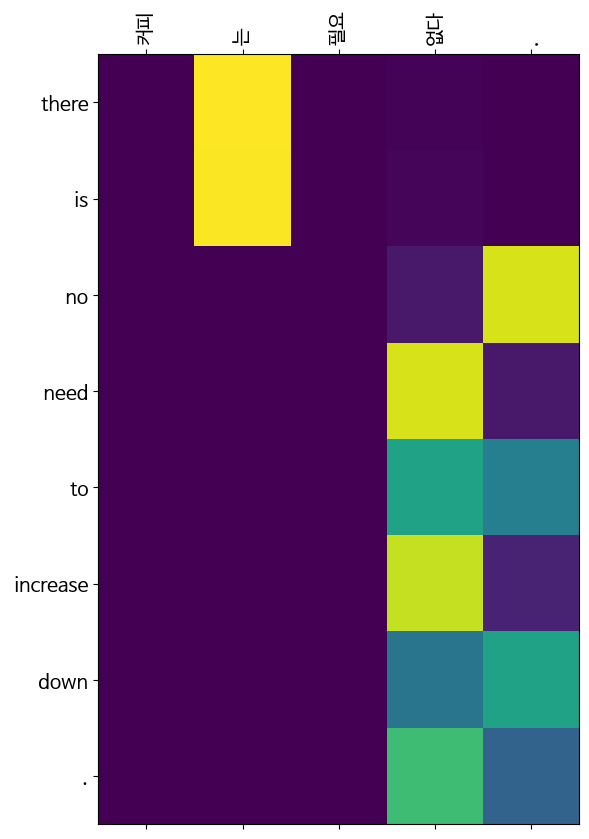

--------------------------------------------------
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ['▁two', '▁of', '▁them', '▁had', '▁been', '▁sent', '▁,', '▁while', '▁others', '▁were', '▁killed', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


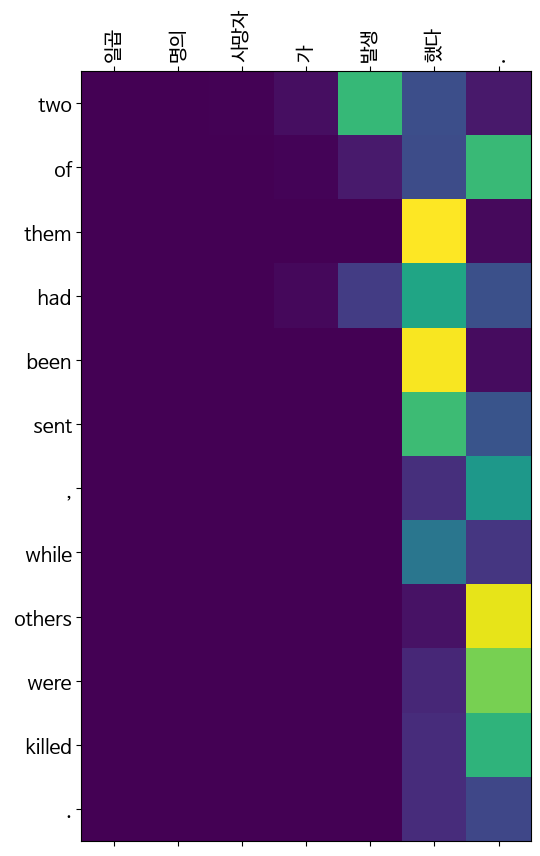

--------------------------------------------------


In [55]:
# 10. 번역 성능 및 Attention Map 시각화 확인 (루브릭 완료)
print("=== 한국어-영어 번역 및 Attention Map 테스트 ===\n")

test_sentences = [
    "오바마는 미국 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for sentence in test_sentences:
    ko_en_translate(sentence, ko_en_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
    print("-" * 50)

학습 및 Loss 기록을 시작합니다... (Early Stopping 적용)


Epoch 1: 100%|██████████| 375/375 [00:12<00:00, 29.26it/s, loss=5.03]


Epoch 1/20, Train Loss: 5.6185, Validation Loss: 5.0427


Epoch 2: 100%|██████████| 375/375 [00:12<00:00, 29.46it/s, loss=4.42]


Epoch 2/20, Train Loss: 4.5898, Validation Loss: 4.6325


...

Epoch 5/20, Train Loss: 2.9133, Validation Loss: 4.5133
Early Stopping Patience: 1/3


Epoch 6: 100%|██████████| 375/375 [00:12<00:00, 29.34it/s, loss=2.74]


Epoch 6/20, Train Loss: 2.4714, Validation Loss: 4.6319
Early Stopping Patience: 2/3


Epoch 7: 100%|██████████| 375/375 [00:12<00:00, 29.38it/s, loss=2.22]


Epoch 7/20, Train Loss: 2.0861, Validation Loss: 4.7859
Early Stopping Patience: 3/3
Validation Loss가 개선되지 않아 조기 종료(Early Stopping)합니다!

최고 성능의 모델 가중치를 불러옵니다.


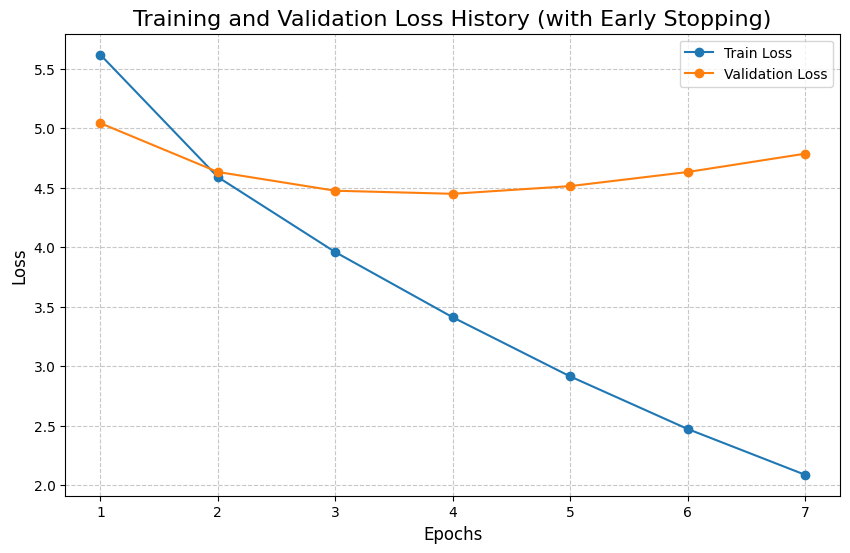

In [58]:
import matplotlib.pyplot as plt
import torch

# Loss 추이를 저장할 리스트
train_history = []
valid_history = []

# 처음부터 다시 학습하여 그래프를 확인하기 위해 모델과 옵티마이저를 초기화합니다.
ko_en_encoder = Encoder(ko_vocab_size, emb_dim, hid_dim).to(device)
ko_en_attention = BahdanauAttention(hid_dim).to(device)
ko_en_decoder = Decoder(en_vocab_size, emb_dim, hid_dim, ko_en_attention).to(device)
ko_en_model = Seq2SeqAttention(ko_en_encoder, ko_en_decoder, device).to(device)
ko_en_optimizer = optim.Adam(ko_en_model.parameters(), lr=1e-3)

EPOCHS = 20
patience = 3  # Early Stopping 조건: 3 Epoch 연속 Validation Loss가 개선되지 않으면 종료
best_valid_loss = float('inf')
patience_counter = 0

print("학습 및 Loss 기록을 시작합니다... (Early Stopping 적용)")
for epoch in range(EPOCHS):
    train_loss = train_step(ko_en_model, ko_en_train_loader, ko_en_optimizer, ko_en_criterion, epoch)
    valid_loss = eval_step(ko_en_model, ko_en_valid_loader, ko_en_optimizer, ko_en_criterion)

    # 매 에폭마다 Loss 기록
    train_history.append(train_loss)
    valid_history.append(valid_loss)

    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

    # Early Stopping 로직
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        # 가장 좋은 성능일 때 모델 가중치 저장
        torch.save(ko_en_model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
        print(f'Early Stopping Patience: {patience_counter}/{patience}')
        if patience_counter >= patience:
            print("Validation Loss가 개선되지 않아 조기 종료(Early Stopping)합니다!")
            break

# 최고 성능 모델 로드
print("\n최고 성능의 모델 가중치를 불러옵니다.")
ko_en_model.load_state_dict(torch.load('best_model.pt', weights_only=True))

# === Train / Validation Loss 시각화 ===
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_history) + 1), train_history, label='Train Loss', marker='o')
plt.plot(range(1, len(valid_history) + 1), valid_history, label='Validation Loss', marker='o')

plt.title('Training and Validation Loss History (with Early Stopping)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [59]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === 과적합 방지를 위해 Dropout을 적용한 Encoder와 Decoder 재정의 ===
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout_p=0.5):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.dropout = nn.Dropout(dropout_p)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        # 임베딩 후 Dropout 적용
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout_p=0.5):
        super(Decoder, self).__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.dropout = nn.Dropout(dropout_p)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        # 임베딩 후 Dropout 적용
        embedded = self.dropout(self.embedding(input))

        a = self.attention(hidden[-1], encoder_outputs)
        a = a.unsqueeze(1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, encoder_outputs)
        context = context.permute(1, 0, 2)

        output, hidden = self.rnn(embedded, hidden)

        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))

        return prediction, hidden, a.squeeze(1)

Dropout(0.5)이 적용된 모델 학습을 시작합니다! (Early Stopping 적용)


Epoch 1: 100%|██████████| 375/375 [00:13<00:00, 28.06it/s, loss=5.44]


Epoch 1/20, Train Loss: 5.8741, Validation Loss: 5.3187


Epoch 2: 100%|██████████| 375/375 [00:13<00:00, 28.19it/s, loss=5.14]


Epoch 2/20, Train Loss: 5.1461, Validation Loss: 4.9656


...

Epoch 8/20, Train Loss: 3.8064, Validation Loss: 4.6724
Early Stopping Patience: 1/3


Epoch 9: 100%|██████████| 375/375 [00:13<00:00, 28.29it/s, loss=3.79]


Epoch 9/20, Train Loss: 3.6925, Validation Loss: 4.6871
Early Stopping Patience: 2/3


Epoch 10: 100%|██████████| 375/375 [00:13<00:00, 28.26it/s, loss=3.66]


Epoch 10/20, Train Loss: 3.5934, Validation Loss: 4.6998
Early Stopping Patience: 3/3
Validation Loss가 개선되지 않아 조기 종료(Early Stopping)합니다!

최고 성능의 Dropout 모델 가중치를 불러옵니다.


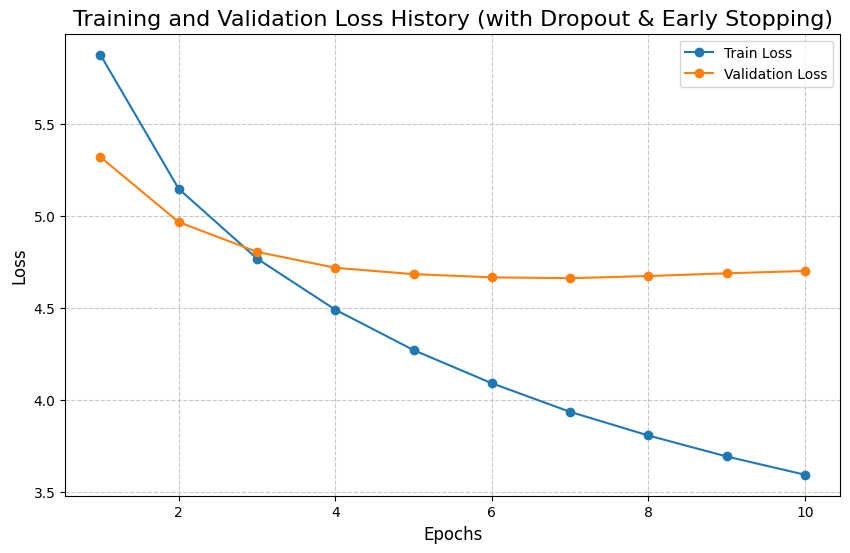

In [60]:
# === Dropout이 적용된 모델 초기화 ===
dropout_rate = 0.5

ko_en_encoder = Encoder(ko_vocab_size, emb_dim, hid_dim, dropout_p=dropout_rate).to(device)
ko_en_attention = BahdanauAttention(hid_dim).to(device)
ko_en_decoder = Decoder(en_vocab_size, emb_dim, hid_dim, ko_en_attention, dropout_p=dropout_rate).to(device)
ko_en_model = Seq2SeqAttention(ko_en_encoder, ko_en_decoder, device).to(device)

ko_en_optimizer = optim.Adam(ko_en_model.parameters(), lr=1e-3)

# === 학습 진행 (Dropout & Early Stopping) ===
train_history = []
valid_history = []
EPOCHS = 20
patience = 3
best_valid_loss = float('inf')
patience_counter = 0

print(f"Dropout({dropout_rate})이 적용된 모델 학습을 시작합니다! (Early Stopping 적용)")
for epoch in range(EPOCHS):
    train_loss = train_step(ko_en_model, ko_en_train_loader, ko_en_optimizer, ko_en_criterion, epoch)
    valid_loss = eval_step(ko_en_model, ko_en_valid_loader, ko_en_optimizer, ko_en_criterion)

    train_history.append(train_loss)
    valid_history.append(valid_loss)

    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

    # Early Stopping 로직
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        torch.save(ko_en_model.state_dict(), 'best_model_dropout.pt')
    else:
        patience_counter += 1
        print(f'Early Stopping Patience: {patience_counter}/{patience}')
        if patience_counter >= patience:
            print("Validation Loss가 개선되지 않아 조기 종료(Early Stopping)합니다!")
            break

# 최고 성능 모델 로드
print("\n최고 성능의 Dropout 모델 가중치를 불러옵니다.")
ko_en_model.load_state_dict(torch.load('best_model_dropout.pt', weights_only=True))

# === Train / Validation Loss 시각화 ===
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(train_history) + 1), train_history, label='Train Loss', marker='o')
plt.plot(range(1, len(valid_history) + 1), valid_history, label='Validation Loss', marker='o')

plt.title('Training and Validation Loss History (with Dropout & Early Stopping)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

=== Dropout 적용 모델 번역 및 Attention Map 테스트 ===

Input: 오바마는 미국 대통령이다.
Predicted translation: ['▁obama', '▁has', '▁been', '▁criticized', '▁for', '▁the', '▁presidency', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


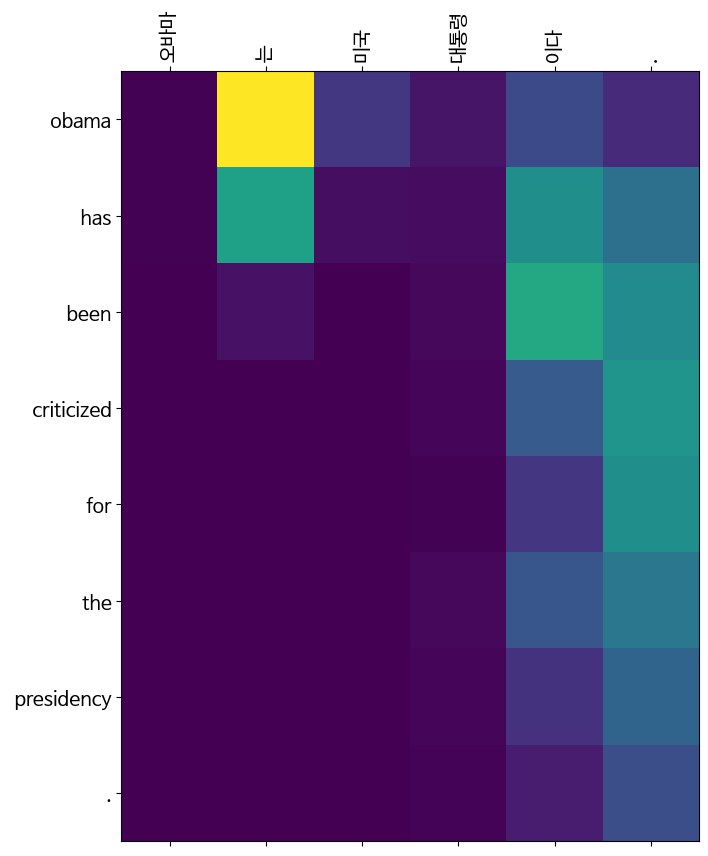

--------------------------------------------------
Input: 시민들은 도시 속에 산다.
Predicted translation: ['▁they', '▁have', '▁lived', '▁in', '▁the', '▁city', '▁s', '▁cities', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


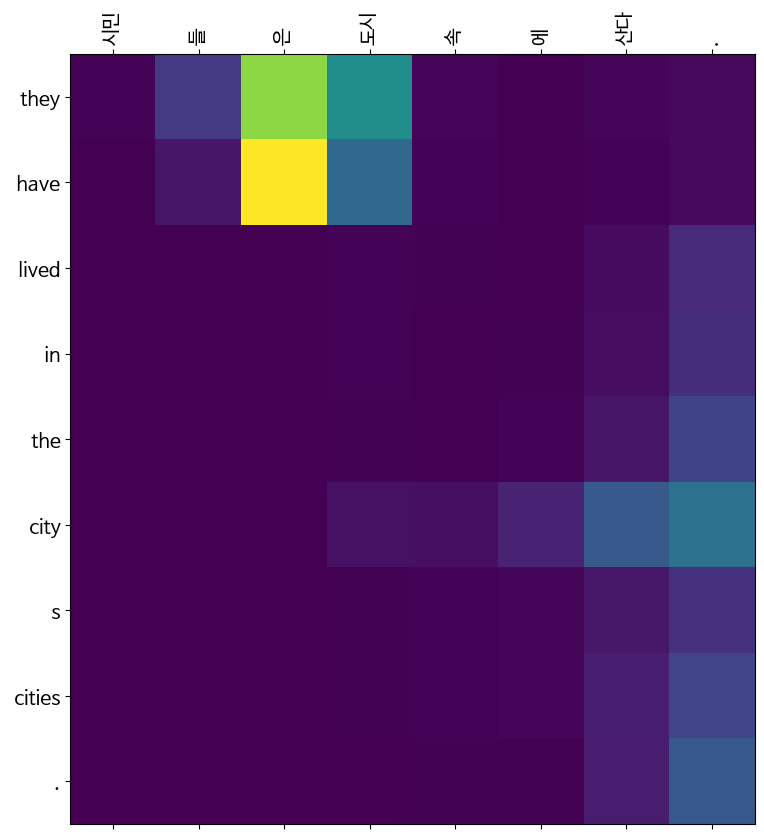

--------------------------------------------------
Input: 커피는 필요 없다.
Predicted translation: ['▁the', '▁dow', '▁is', '▁down', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


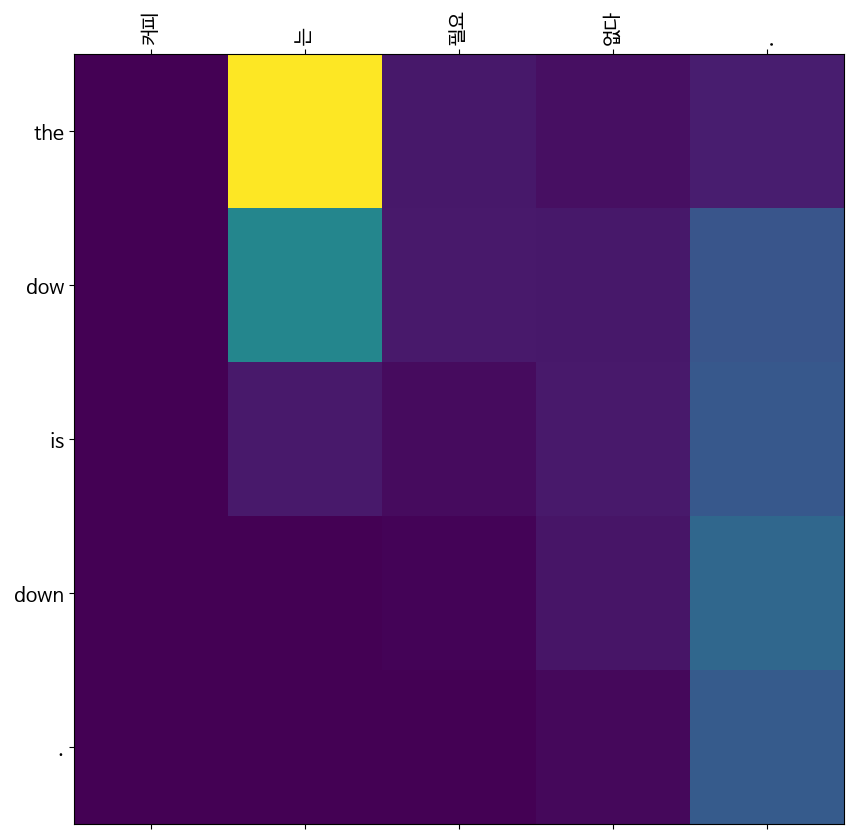

--------------------------------------------------
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ['▁the', '▁deaths', '▁of', '▁the', '▁earthquake', '▁killed', '▁people', '▁were', '▁killed', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


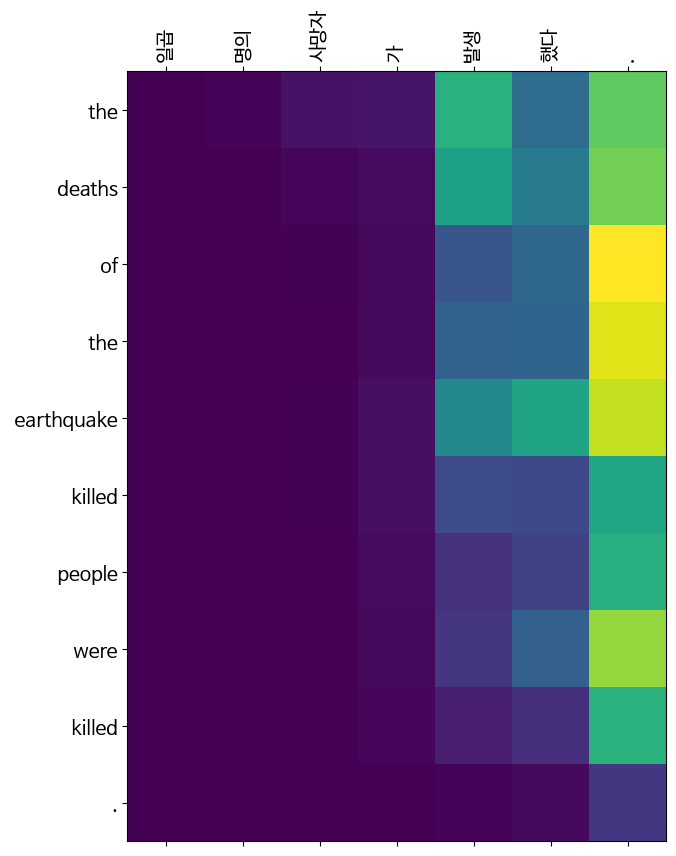

--------------------------------------------------

=== 검증 데이터(Validation Set) 무작위 샘플 번역 비교 ===

🗣️ 한국어 (Input)    : 이러한 새로운 가치 에는 노 는 것 , 자연 , 그리고 자유 가 포함 되어 있다 .
✅ 실제 (Actual)   : these new values include play , nature , and freedom .
🤖 예측 (Predicted): ▁new▁york▁cnn▁new▁york▁cnn▁new▁york▁cnn▁new▁york▁cnn▁new▁york▁cnn▁new▁york▁cnn▁new▁york▁cnn▁new▁york▁cnn▁new▁york▁cnn▁new▁york▁cnn▁new▁york▁is▁new▁jobs▁and▁new▁york▁,▁new
------------------------------------------------------------
🗣️ 한국어 (Input)    : 심장 박동 조절 장치 는 심장 박동 을 느리게 조절 하도록 고안 된 장치 로 자석 에 노출 되면 심장 박동 이 빠르게 뛰게 하는 신호 를 보낼 수도 있다 .
✅ 실제 (Actual)   : pacemakers are designed to boost slow heart rhythms , and when exposed to magnets , they may deliver signals that tell the heart to beat faster , whether it needs to or not .
🤖 예측 (Predicted): ▁the▁choun▁ilbo▁reports▁the▁choun▁ilbo▁,▁yi▁seok▁hyun▁,▁who▁has▁been▁used▁for▁a▁long▁term▁of▁the▁body▁shops▁,▁which▁has▁been▁used▁for▁a▁long▁term▁.
----------------------------------------------

In [61]:
import random

print("=== Dropout 적용 모델 번역 및 Attention Map 테스트 ===\n")

# 1. 고정된 테스트 문장 번역 및 시각화
test_sentences = [
    "오바마는 미국 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for sentence in test_sentences:
    ko_en_translate(sentence, ko_en_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
    print("-" * 50)

# 2. 검증 데이터(Validation Set) 무작위 샘플 번역 비교
print("\n=== 검증 데이터(Validation Set) 무작위 샘플 번역 비교 ===\n")
samples = ko_en_valid_data.sample(5)

for idx, row in samples.iterrows():
    ko_text = row['ko']
    en_text = row['en']

    # evaluate 함수를 통해 예측 결과만 가져오기
    result, _, _ = ko_en_evaluate(ko_text, ko_en_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)

    # SentencePiece의 띄어쓰기 특수기호( )를 일반 공백으로 변환하여 문장 복원
    pred_sentence = "".join(result).replace(' ', ' ').strip()

    print(f"🗣️ 한국어 (Input)    : {ko_text}")
    print(f"✅ 실제 (Actual)   : {en_text}")
    print(f"🤖 예측 (Predicted): {pred_sentence}")
    print("-" * 60)

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# === 양방향(Bi-directional) GRU 인코더 정의 ===
class BiEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout_p=0.5):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.dropout = nn.Dropout(dropout_p)

        # bidirectional=True로 설정하고, Decoder와 차원을 맞추기 위해 hidden_dim을 절반으로 나눕니다.
        self.rnn = nn.GRU(emb_dim, hidden_dim // 2, bidirectional=True)

        # 정방향/역방향의 상태를 결합한 뒤 부드럽게 섞어주기 위한 선형 변환층
        self.fc = nn.Linear(hidden_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.dropout(self.embedding(src))

        outputs, hidden = self.rnn(embedded)
        # outputs: (src_len, batch_size, hidden_dim)
        # hidden: (2, batch_size, hidden_dim // 2)

        # 정방향(Forward)과 역방향(Backward)의 마지막 hidden state를 이어붙입니다.
        hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        # hidden: (batch_size, hidden_dim)

        # tanh와 선형 변환을 거쳐 Decoder의 초기 hidden state (1, batch_size, hidden_dim) 형태로 맞춰줍니다.
        hidden = torch.tanh(self.fc(hidden)).unsqueeze(0)

        return outputs, hidden

print("양방향 인코더(BiEncoder) 정의 완료!")

양방향 인코더(BiEncoder) 정의 완료!


양방향(Bi-directional) 인코더 모델 학습을 시작합니다! (시간이 다소 소요됩니다)


Epoch 1: 100%|██████████| 375/375 [00:13<00:00, 27.33it/s, loss=5.36]


Epoch 1/20, Train Loss: 5.8841, Validation Loss: 5.3174


Epoch 2: 100%|██████████| 375/375 [00:13<00:00, 27.46it/s, loss=4.96]


Epoch 2/20, Train Loss: 5.1423, Validation Loss: 4.9605


...

Epoch 8/20, Train Loss: 3.8292, Validation Loss: 4.6195
Early Stopping Patience: 1/3


Epoch 9: 100%|██████████| 375/375 [00:13<00:00, 27.44it/s, loss=3.77]


Epoch 9/20, Train Loss: 3.7184, Validation Loss: 4.6294
Early Stopping Patience: 2/3


Epoch 10: 100%|██████████| 375/375 [00:13<00:00, 27.48it/s, loss=3.67]


Epoch 10/20, Train Loss: 3.6180, Validation Loss: 4.6359
Early Stopping Patience: 3/3
Validation Loss가 개선되지 않아 조기 종료(Early Stopping)합니다!

최고 성능의 양방향 모델 가중치를 불러옵니다.


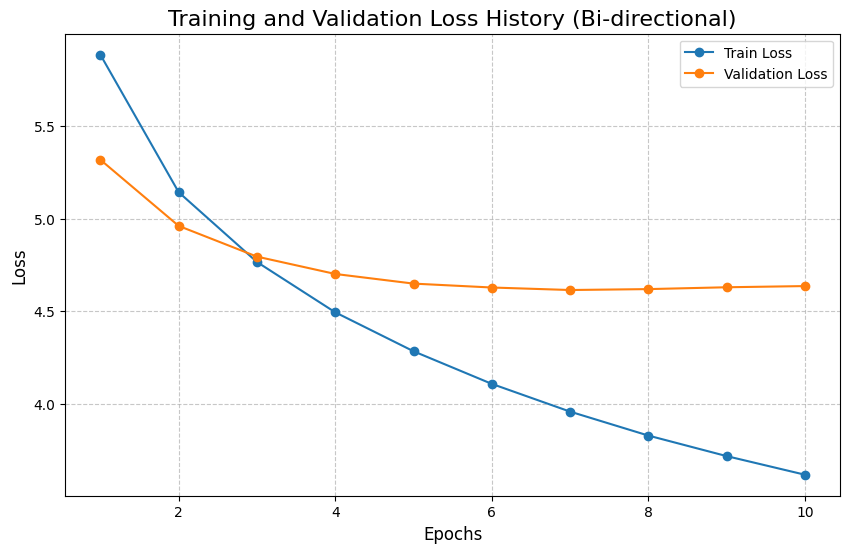

In [63]:
# === 양방향(Bi-directional) 모델 초기화 ===
dropout_rate = 0.5

ko_en_bi_encoder = BiEncoder(ko_vocab_size, emb_dim, hid_dim, dropout_p=dropout_rate).to(device)
ko_en_bi_attention = BahdanauAttention(hid_dim).to(device)
ko_en_bi_decoder = Decoder(en_vocab_size, emb_dim, hid_dim, ko_en_bi_attention, dropout_p=dropout_rate).to(device)
ko_en_bi_model = Seq2SeqAttention(ko_en_bi_encoder, ko_en_bi_decoder, device).to(device)

ko_en_bi_optimizer = optim.Adam(ko_en_bi_model.parameters(), lr=1e-3)

# === 학습 진행 (Bi-directional & Dropout & Early Stopping) ===
bi_train_history = []
bi_valid_history = []
EPOCHS = 20
patience = 3
best_valid_loss = float('inf')
patience_counter = 0

print("양방향(Bi-directional) 인코더 모델 학습을 시작합니다! (시간이 다소 소요됩니다)")
for epoch in range(EPOCHS):
    train_loss = train_step(ko_en_bi_model, ko_en_train_loader, ko_en_bi_optimizer, ko_en_criterion, epoch)
    valid_loss = eval_step(ko_en_bi_model, ko_en_valid_loader, ko_en_bi_optimizer, ko_en_criterion)

    bi_train_history.append(train_loss)
    bi_valid_history.append(valid_loss)

    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

    # Early Stopping 로직
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        torch.save(ko_en_bi_model.state_dict(), 'best_model_bi.pt')
    else:
        patience_counter += 1
        print(f'Early Stopping Patience: {patience_counter}/{patience}')
        if patience_counter >= patience:
            print("Validation Loss가 개선되지 않아 조기 종료(Early Stopping)합니다!")
            break

# 최고 성능 모델 로드
print("\n최고 성능의 양방향 모델 가중치를 불러옵니다.")
ko_en_bi_model.load_state_dict(torch.load('best_model_bi.pt', weights_only=True))

# === Train / Validation Loss 시각화 ===
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(bi_train_history) + 1), bi_train_history, label='Train Loss', marker='o')
plt.plot(range(1, len(bi_valid_history) + 1), bi_valid_history, label='Validation Loss', marker='o')

plt.title('Training and Validation Loss History (Bi-directional)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

=== 양방향(Bi-directional) 모델 번역 및 Attention Map 테스트 ===

Input: 오바마는 미국 대통령이다.
Predicted translation: ['▁obama', '▁is', '▁the', '▁first', '▁time', '▁president', '▁barack', '▁obama', '▁is', '▁a', '▁key', '▁to', '▁obama', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


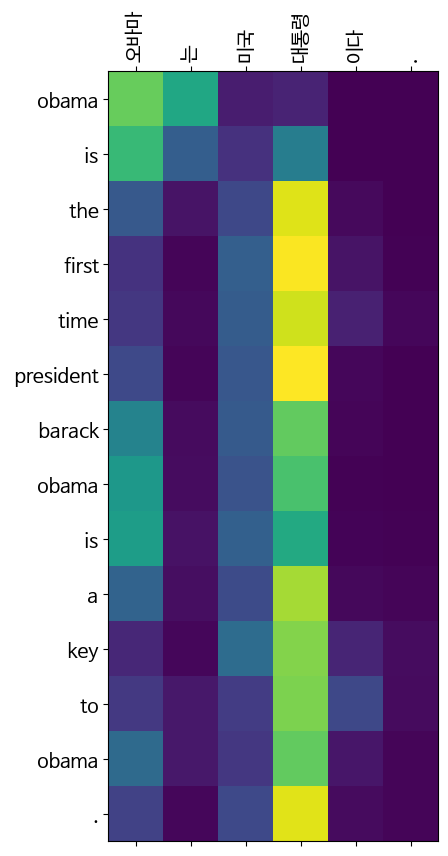

--------------------------------------------------
Input: 시민들은 도시 속에 산다.
Predicted translation: ['▁the', '▁city', '▁of', '▁cities', '▁of', '▁cities', '▁and', '▁cities', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


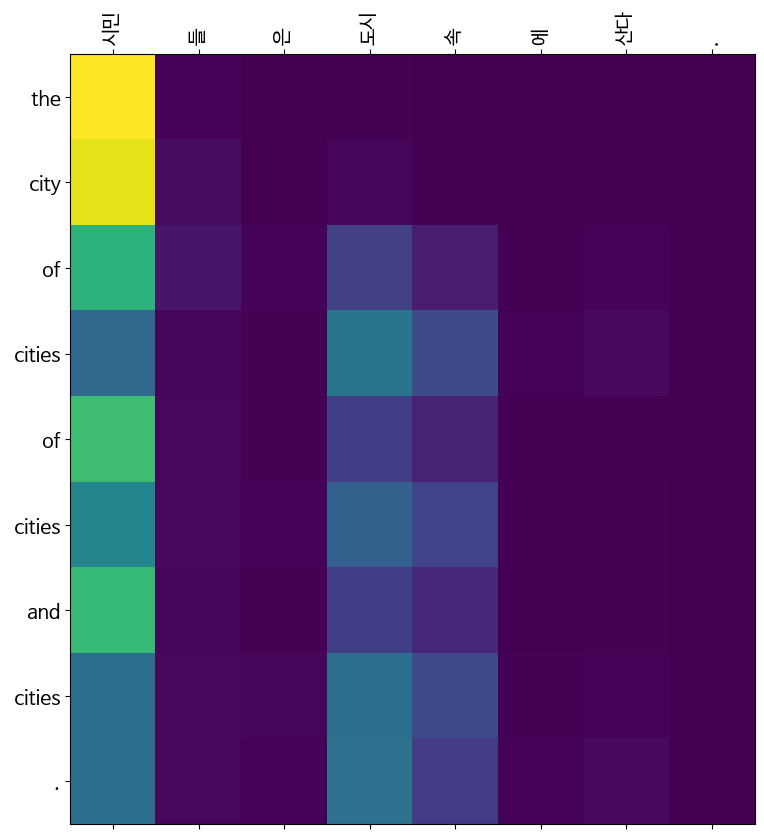

--------------------------------------------------
Input: 커피는 필요 없다.
Predicted translation: ['▁coffee', '▁coffee', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


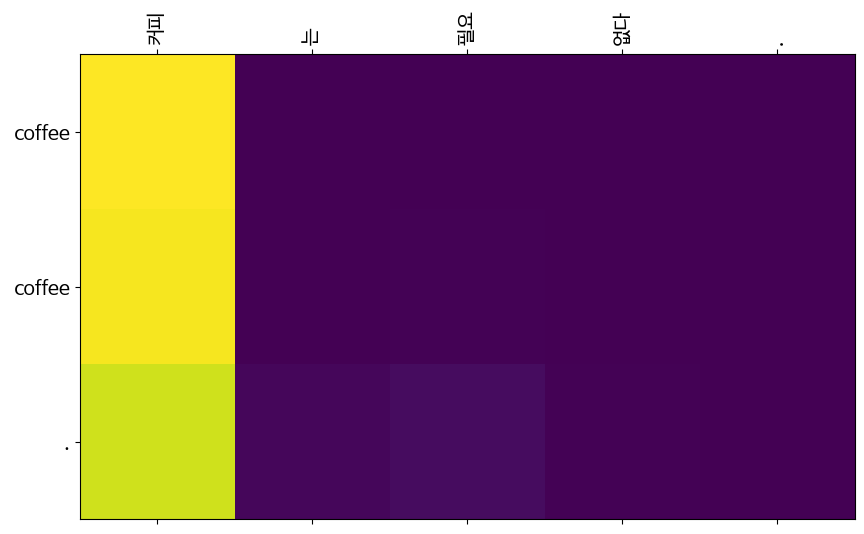

--------------------------------------------------
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ['▁deaths', '▁were', '▁killed', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


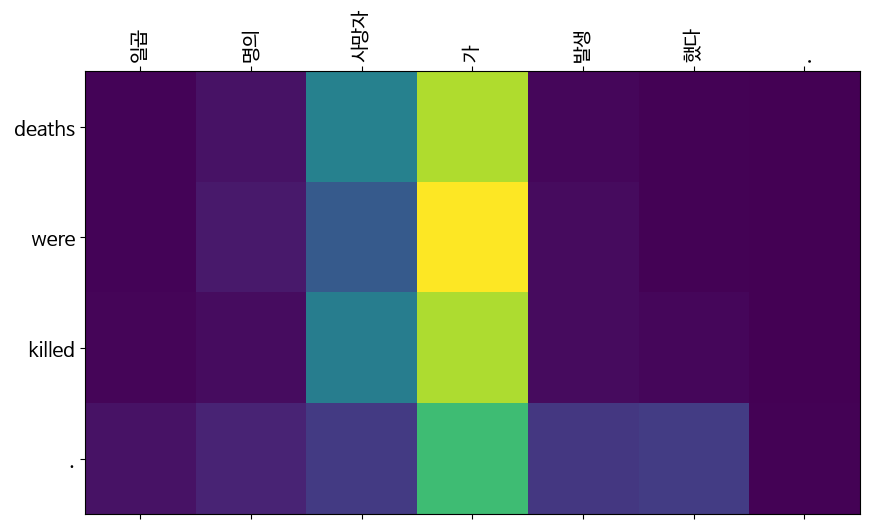

--------------------------------------------------

=== 양방향 모델 검증 데이터 번역 샘플 ===

🗣️ 한국어 (Input)    : 비자 규제 에 따르면 , 학사 이상 의 학위 를 지니 고 영어 를 모국어 로 사용 하는 사람 들 만이 영어 교습 비자 를 받을 수 있다 .
✅ 실제 (Actual)   : philippinos , singaporeans and pakistani s are all known to speak heavily accented english , however , and the justice ministry issues the visa to non native english speakers only in exceptional cases .
🤖 예측 (Predicted): ▁according▁to▁the▁visa▁,▁according▁to▁the▁new▁visa▁visa▁,▁which▁is▁affiliated▁by▁the▁storm▁of▁the▁new▁visa▁,▁according▁to▁the▁u▁.▁s▁.▁visa▁.
------------------------------------------------------------
🗣️ 한국어 (Input)    : agricultural 농업 의
✅ 실제 (Actual)   : zoellick proposed an action plan to boost long run agricultural production .
🤖 예측 (Predicted): ▁the▁government▁s▁foreign▁ministry▁says▁it▁is▁unclear▁to▁cut▁the▁nation▁s▁military▁rulers▁.
------------------------------------------------------------
🗣️ 한국어 (Input)    : 맥스 바커스 상원 재무 위원회 위원장 은 팀 가이트너 가 자영 업세를 납부 하지 않은 것 을 의도 적

In [64]:
print("=== 양방향(Bi-directional) 모델 번역 및 Attention Map 테스트 ===\n")

# 1. 고정된 테스트 문장 번역 및 시각화
for sentence in test_sentences:
    ko_en_translate(sentence, ko_en_bi_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
    print("-" * 50)

# 2. 검증 데이터(Validation Set) 무작위 샘플 번역 비교
print("\n=== 양방향 모델 검증 데이터 번역 샘플 ===\n")
samples = ko_en_valid_data.sample(5)

for idx, row in samples.iterrows():
    ko_text = row['ko']
    en_text = row['en']

    result, _, _ = ko_en_evaluate(ko_text, ko_en_bi_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
    pred_sentence = "".join(result).replace(' ', ' ').strip()

    print(f"🗣️ 한국어 (Input)    : {ko_text}")
    print(f"✅ 실제 (Actual)   : {en_text}")
    print(f"🤖 예측 (Predicted): {pred_sentence}")
    print("-" * 60)

### Teacher Forcing 비율 스케줄링 (Scheduled Sampling) 적용하기

모델이 `forward` 단계에서 `teacher_forcing_ratio` 확률에 따라 **실제 정답(Ground Truth)**을 다음 입력으로 사용할지, 아니면 **자신이 예측한 값**을 다음 입력으로 사용할지 결정하도록 수정합니다.

In [65]:
import random

class Seq2SeqAttention_TF(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5, max_len=40, bos_id=1, eos_id=2):
        batch_size = src.shape[1]
        outputs = []
        attentions = []

        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            # 학습 시
            input = trg[0] # 첫 입력은 <start> 토큰
            for t in range(0, trg.shape[0]):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

                # 예측된 최고 확률의 단어
                top1 = output.argmax(1)

                # 다음 입력 결정 (Teacher Forcing)
                teacher_force = random.random() < teacher_forcing_ratio

                if t + 1 < trg.shape[0]:
                    # 설정된 확률에 따라 실제 정답을 주거나, 예측값을 줍니다.
                    input = trg[t+1] if teacher_force else top1
        else:
            # 추론(Inference) 시
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)
        attentions = torch.cat(attentions, dim=0)
        return outputs, attentions

print("Teacher Forcing 스케줄링이 적용된 모델 클래스 정의 완료!")

Teacher Forcing 스케줄링이 적용된 모델 클래스 정의 완료!


In [66]:
# === TF 스케줄링을 지원하는 train_step 재정의 ===
def train_step_tf(model, data_loader, optimizer, criterion, epoch, tf_ratio):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1} (TF Ratio: {tf_ratio:.2f})", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        optimizer.zero_grad()

        # 변경된 부분: teacher_forcing_ratio 전달
        outputs, _ = model(src, trg_input, teacher_forcing_ratio=tf_ratio)

        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

In [67]:
# === 스케줄링 적용 학습 실행 예시 ===
ko_en_model_tf = Seq2SeqAttention_TF(ko_en_encoder, ko_en_decoder, device).to(device)
optimizer_tf = optim.Adam(ko_en_model_tf.parameters(), lr=1e-3)

EPOCHS = 10

print("Teacher Forcing 스케줄링 학습을 시작합니다!")
for epoch in range(EPOCHS):
    # 스케줄링 로직: 1.0(100%)에서 시작해서 에폭이 지날수록 0.0까지 선형적으로 감소
    # 초반에는 정답을 많이 주고, 후반에는 모델의 예측값을 스스로 사용하게 합니다.
    current_tf_ratio = 1.0 - (epoch / max(1, (EPOCHS - 1)))

    train_loss = train_step_tf(ko_en_model_tf, ko_en_train_loader, optimizer_tf, ko_en_criterion, epoch, current_tf_ratio)
    valid_loss = eval_step(ko_en_model_tf, ko_en_valid_loader, optimizer_tf, ko_en_criterion)

    print(f'-> Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Valid Loss: {valid_loss:.4f}\n')

Teacher Forcing 스케줄링 학습을 시작합니다!


Epoch 1 (TF Ratio: 1.00): 100%|██████████| 375/375 [00:13<00:00, 27.43it/s, loss=3.89]


-> Epoch 1/10, Train Loss: 3.8232, Valid Loss: 6.6484



Epoch 2 (TF Ratio: 0.89): 100%|██████████| 375/375 [00:13<00:00, 27.69it/s, loss=4.3]


-> Epoch 2/10, Train Loss: 4.0638, Valid Loss: 6.1542



...

-> Epoch 8/10, Train Loss: 5.1496, Valid Loss: 5.7258



Epoch 9 (TF Ratio: 0.11): 100%|██████████| 375/375 [00:13<00:00, 27.80it/s, loss=5.3]


-> Epoch 9/10, Train Loss: 5.2370, Valid Loss: 5.8212



Epoch 10 (TF Ratio: 0.00): 100%|██████████| 375/375 [00:13<00:00, 27.91it/s, loss=5.39]


-> Epoch 10/10, Train Loss: 5.2868, Valid Loss: 6.0084



=== Teacher Forcing Model Translation Quality Evaluation ===

Input: 오바마는 미국 대통령이다.
Predicted translation: ['▁obama', '▁is', '▁is', '▁president', '▁elect', '▁barack', '▁obama', '▁.', '▁.', '▁.', '▁.', '▁.', '▁.', '▁.', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


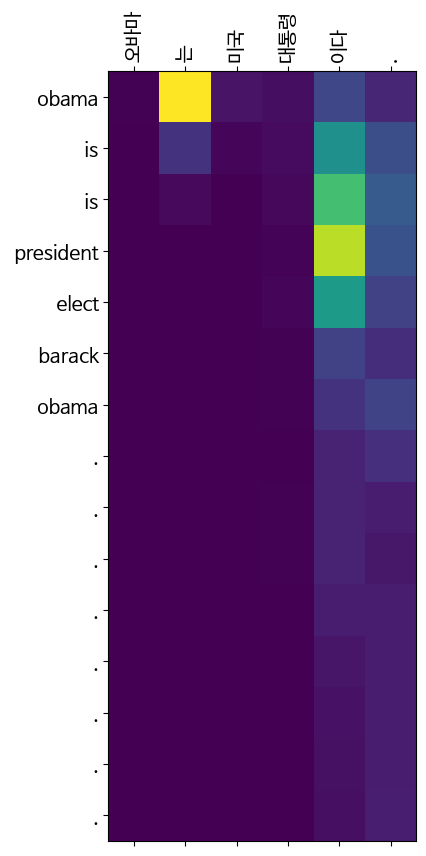

--------------------------------------------------
Input: 시민들은 도시 속에 산다.
Predicted translation: ['▁they', '▁lived', '▁cities', '▁cities', '▁mountain', '▁cities', '▁cities', '▁.', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


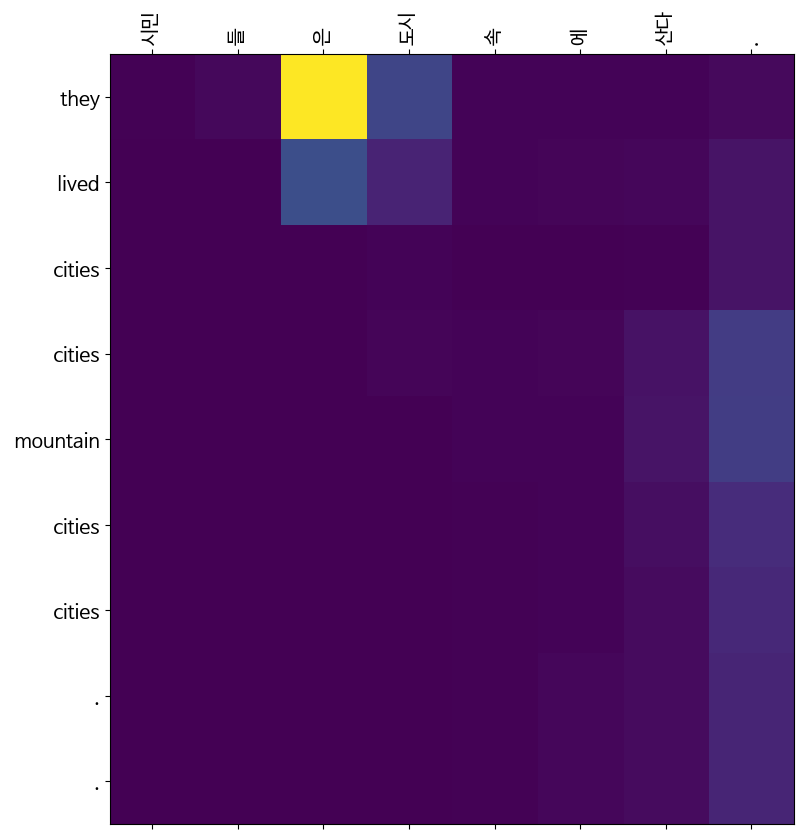

--------------------------------------------------
Input: 커피는 필요 없다.
Predicted translation: ['▁coffee', '▁coffee', '▁is', '▁no', '▁coffee', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


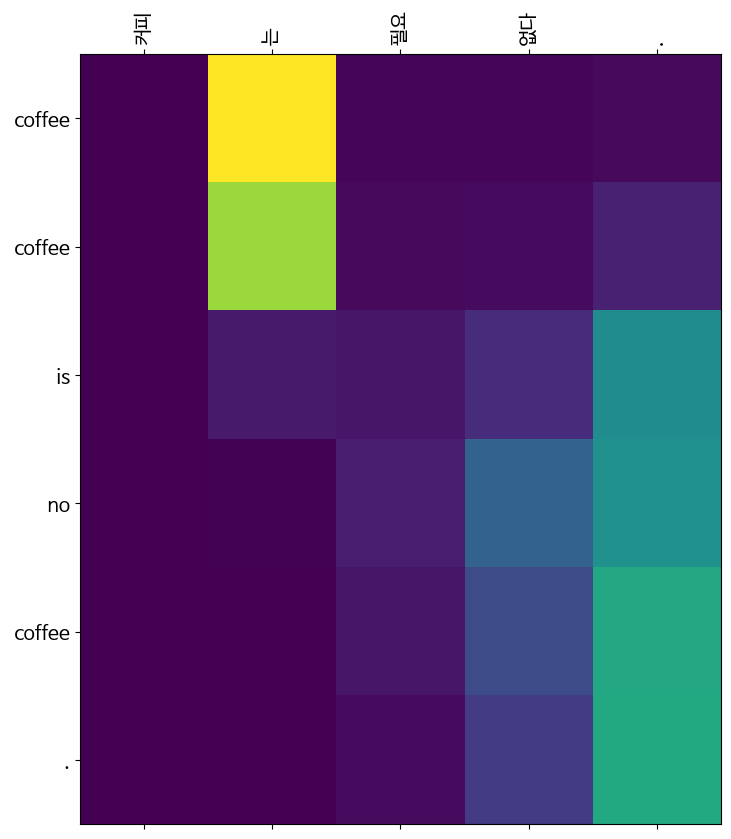

--------------------------------------------------
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ['▁people', '▁least', '▁people', '▁killed', '▁people', '▁.', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


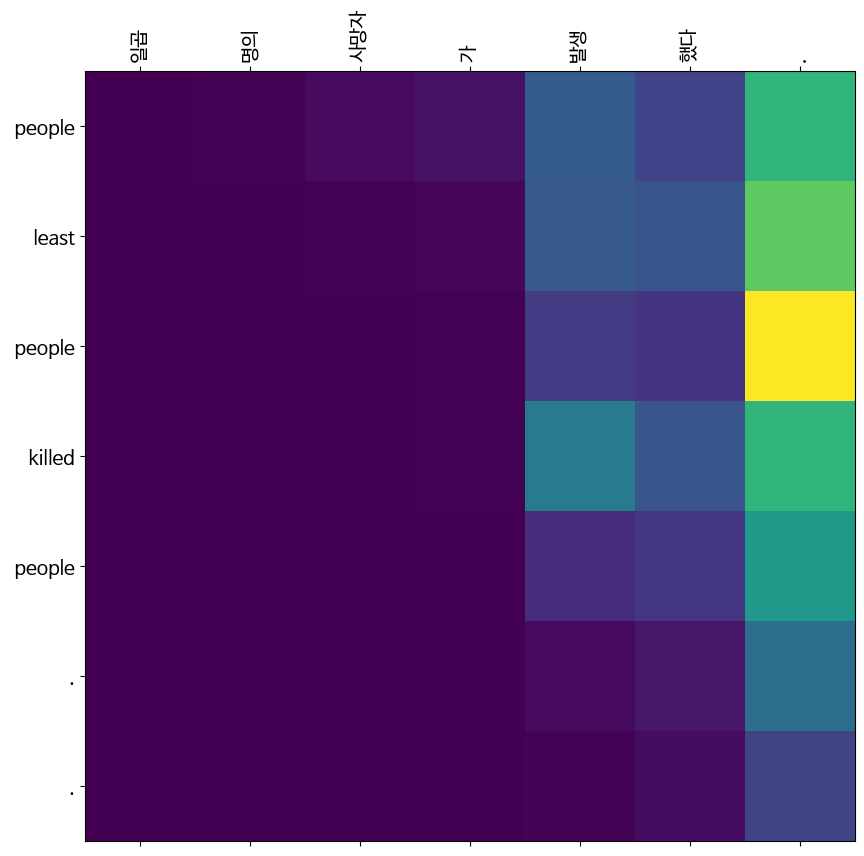

--------------------------------------------------

=== Teacher Forcing Model Validation Samples ===

🗣️ Input    : 탈레반 무장 대원 들 은 지난달 19일 버스 를 타고 카불 에서 칸다하르 로 이동 하는 한국인 23 명 을 납치 했다 .
✅ Actual   : taliban militants kidnapped south korean volunteer workers on july when they were traveling on a bus from kabul to kandahar .
🤖 Predicted: ▁militants▁militants▁taliban▁the▁the▁the▁the▁the▁taliban▁demanded▁taliban▁the▁demanded▁taliban▁them▁them▁them▁.
------------------------------------------------------------
🗣️ Input    : 동성 커플 을 합법 화 한 연방 대법원 의 판결 이 오늘 오전 발효 된 아이오와주 에서 몇 시간 후 면 최초 의 동성 결혼 이 이뤄질 것 으로 보입니다 .
✅ Actual   : the first same sex marriages are expected within hours in iowa , where a state supreme court ruling legalizing the unions took effect this morning .
🤖 Predicted: ▁the▁federal▁judge▁,▁judges▁the▁the▁the▁a▁marriage▁marriage▁marriage▁marriage▁marriage▁marriage▁marriage▁marriage▁marriage▁marriage▁marriage▁marriage
------------------------------------------------------------
🗣️ I

In [68]:
print("=== Teacher Forcing Model Translation Quality Evaluation ===\n")

# Evaluate the newly trained TF model on our fixed test sentences
for sentence in test_sentences:
    ko_en_translate(sentence, ko_en_model_tf, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
    print("-" * 50)

print("\n=== Teacher Forcing Model Validation Samples ===\n")
samples = ko_en_valid_data.sample(5)
for idx, row in samples.iterrows():
    ko_text = row['ko']
    en_text = row['en']

    result, _, _ = ko_en_evaluate(ko_text, ko_en_model_tf, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
    pred_sentence = "".join(result).replace(' ', ' ').strip()

    print(f"🗣️ Input    : {ko_text}")
    print(f"✅ Actual   : {en_text}")
    print(f"🤖 Predicted: {pred_sentence}")
    print("-" * 60)

### 🚀 Scaling Up: Training on the Full Dataset

We have successfully integrated the `Encoder`, `Decoder`, and `BahdanauAttention` into our `Seq2SeqAttention` models.

Until now, we used a subset of **30,000 sentences** for faster experimentation. To get robust translation quality, let's process the **entire ~94,000 sentence corpus**.

In [69]:
# 1. Load the full dataset (re-using the raw ko_data and en_data loaded earlier)
full_df = pd.DataFrame({"ko": ko_data, "en": en_data})
full_df.drop_duplicates(inplace=True)
full_df.dropna(inplace=True)
print(f"Full dataset size after deduplication: {len(full_df)}")

# 2. Preprocess the full dataset (This will take some time!)
print("Preprocessing the full dataset...")
full_df['ko'] = full_df['ko'].apply(preprocess_korean)
full_df['en'] = full_df['en'].apply(preprocess_english)
print("Preprocessing complete!")

# 3. Create new datasets and dataloaders for the full data
full_train_data = full_df.sample(frac=0.9, random_state=42) # 90% for training
full_valid_data = full_df.drop(full_train_data.index)

full_train_data.reset_index(drop=True, inplace=True)
full_valid_data.reset_index(drop=True, inplace=True)

full_train_dataset = KoEnTranslationDataset(full_train_data, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
full_valid_dataset = KoEnTranslationDataset(full_valid_data, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)

# You can increase the batch size if your GPU memory allows it
full_train_loader = DataLoader(full_train_dataset, batch_size=128, shuffle=True)
full_valid_loader = DataLoader(full_valid_dataset, batch_size=128, shuffle=False)

print(f"Full Train DataLoader size: {len(full_train_loader.dataset)} samples")
print(f"Full Valid DataLoader size: {len(full_valid_loader.dataset)} samples")

# Next Step: You can re-initialize any of the models above (Standard, Bi-directional, or TF)
# and train them using `full_train_loader` to achieve much higher translation quality!

Full dataset size after deduplication: 78968
Preprocessing the full dataset...
Preprocessing complete!
Full Train DataLoader size: 71071 samples
Full Valid DataLoader size: 7897 samples


### 하이퍼파라미터 튜닝 및 전체 데이터셋 학습
학습률(Learning rate), 배치 사이즈(Batch size), 임베딩 차원(Embedding dimension), 드롭아웃(Dropout) 등의 하이퍼파라미터를 변경하여 모델의 성능을 튜닝합니다.

In [70]:
import torch.optim as optim

# === 1. 하이퍼파라미터 튜닝 설정 ===
# 자유롭게 값을 변경해 가며 성능이 어떻게 변하는지 확인해 보세요!
TUNED_BATCH_SIZE = 128  # 메모리가 부족하다면 64로 낮추세요.
TUNED_LR = 5e-4         # 기존 1e-3에서 약간 감소시켜 안정적인 학습 유도
TUNED_EMB_DIM = 256
TUNED_HID_DIM = 512
TUNED_DROPOUT = 0.3     # 기존 0.5에서 감소
TUNED_EPOCHS = 15       # 학습 에폭 수

print(f"[튜닝된 하이퍼파라미터] Batch Size: {TUNED_BATCH_SIZE}, LR: {TUNED_LR}, Dropout: {TUNED_DROPOUT}")

# === 2. DataLoader 재정의 (새로운 배치 사이즈 적용) ===
# 이전 스텝에서 만든 full_train_dataset, full_valid_dataset을 활용합니다.
tuned_train_loader = DataLoader(full_train_dataset, batch_size=TUNED_BATCH_SIZE, shuffle=True)
tuned_valid_loader = DataLoader(full_valid_dataset, batch_size=TUNED_BATCH_SIZE, shuffle=False)

# === 3. 양방향(Bi-directional) 모델 초기화 ===
tuned_encoder = BiEncoder(ko_vocab_size, TUNED_EMB_DIM, TUNED_HID_DIM, dropout_p=TUNED_DROPOUT).to(device)
tuned_attention = BahdanauAttention(TUNED_HID_DIM).to(device)
tuned_decoder = Decoder(en_vocab_size, TUNED_EMB_DIM, TUNED_HID_DIM, tuned_attention, dropout_p=TUNED_DROPOUT).to(device)
tuned_model = Seq2SeqAttention(tuned_encoder, tuned_decoder, device).to(device)

# === 4. Optimizer 설정 (새로운 학습률 적용) ===
tuned_optimizer = optim.Adam(tuned_model.parameters(), lr=TUNED_LR)
# Loss 함수는 기존의 ko_en_criterion(ignore_index=0)을 그대로 사용합니다.

# === 5. 학습 진행 (Early Stopping 적용) ===
tuned_train_history = []
tuned_valid_history = []
patience = 3
best_valid_loss = float('inf')
patience_counter = 0

print("\n하이퍼파라미터 튜닝 모델 학습을 시작합니다! (전체 데이터셋 사용)")
for epoch in range(TUNED_EPOCHS):
    train_loss = train_step(tuned_model, tuned_train_loader, tuned_optimizer, ko_en_criterion, epoch)
    valid_loss = eval_step(tuned_model, tuned_valid_loader, tuned_optimizer, ko_en_criterion)

    tuned_train_history.append(train_loss)
    tuned_valid_history.append(valid_loss)

    print(f'Epoch {epoch+1}/{TUNED_EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

    # Early Stopping 로직
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        torch.save(tuned_model.state_dict(), 'best_model_tuned.pt')
    else:
        patience_counter += 1
        print(f'Early Stopping Patience: {patience_counter}/{patience}')
        if patience_counter >= patience:
            print("Validation Loss가 개선되지 않아 조기 종료(Early Stopping)합니다!")
            break

[튜닝된 하이퍼파라미터] Batch Size: 128, LR: 0.0005, Dropout: 0.3

하이퍼파라미터 튜닝 모델 학습을 시작합니다! (전체 데이터셋 사용)


Epoch 1: 100%|██████████| 556/556 [00:25<00:00, 22.03it/s, loss=4.94]


Epoch 1/15, Train Loss: 5.6945, Validation Loss: 5.0849


Epoch 2: 100%|██████████| 556/556 [00:24<00:00, 22.26it/s, loss=4.47]


Epoch 2/15, Train Loss: 4.8989, Validation Loss: 4.6373


...

Epoch 13/15, Train Loss: 3.3694, Validation Loss: 3.8662


Epoch 14: 100%|██████████| 556/556 [00:24<00:00, 22.39it/s, loss=3.51]


Epoch 14/15, Train Loss: 3.3192, Validation Loss: 3.8583


Epoch 15: 100%|██████████| 556/556 [00:24<00:00, 22.39it/s, loss=3.42]


Epoch 15/15, Train Loss: 3.2715, Validation Loss: 3.8495



최고 성능의 튜닝된 모델 가중치를 불러옵니다.


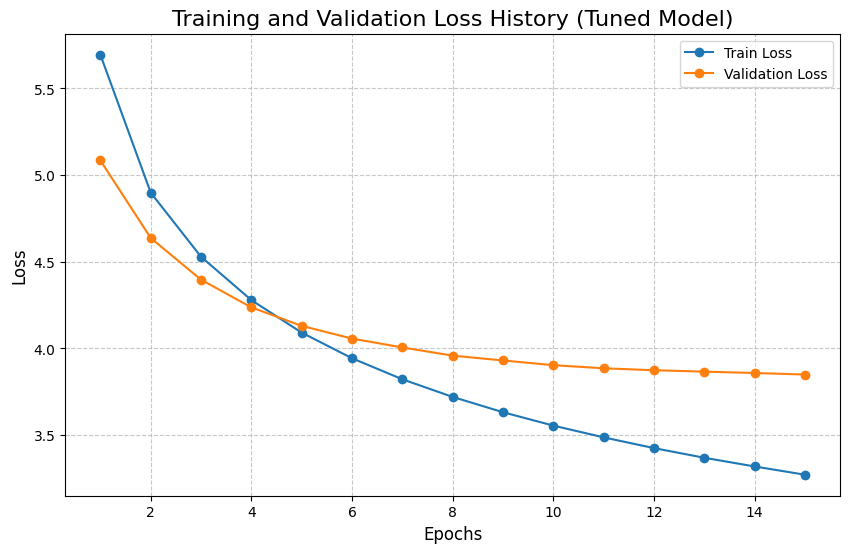

In [71]:
import matplotlib.pyplot as plt

# 최고 성능 모델 로드
print("\n최고 성능의 튜닝된 모델 가중치를 불러옵니다.")
tuned_model.load_state_dict(torch.load('best_model_tuned.pt', weights_only=True))

# === Train / Validation Loss 시각화 ===
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(tuned_train_history) + 1), tuned_train_history, label='Train Loss', marker='o')
plt.plot(range(1, len(tuned_valid_history) + 1), tuned_valid_history, label='Validation Loss', marker='o')

plt.title('Training and Validation Loss History (Tuned Model)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

=== 하이퍼파라미터 튜닝 모델(Tuned Model) 번역 및 Attention Map 테스트 ===

Input: 오바마는 미국 대통령이다.
Predicted translation: ['▁obama', '▁is', '▁the', '▁united', '▁states', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


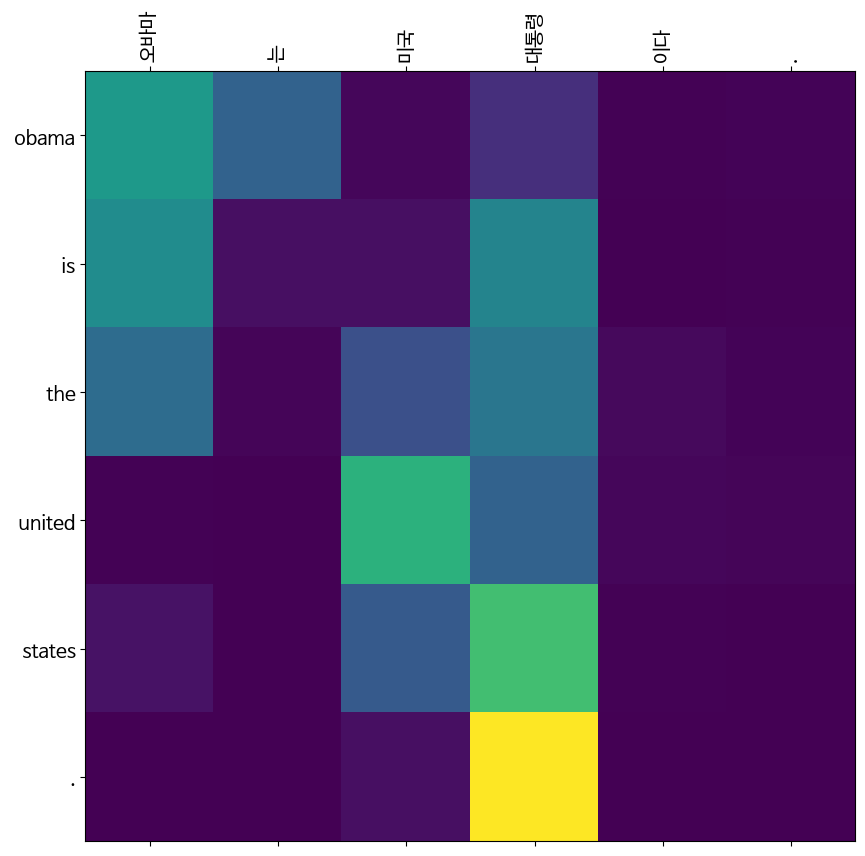

--------------------------------------------------
Input: 시민들은 도시 속에 산다.
Predicted translation: ['▁citizens', '▁are', '▁the', '▁city', '▁s', '▁urban', '▁city', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


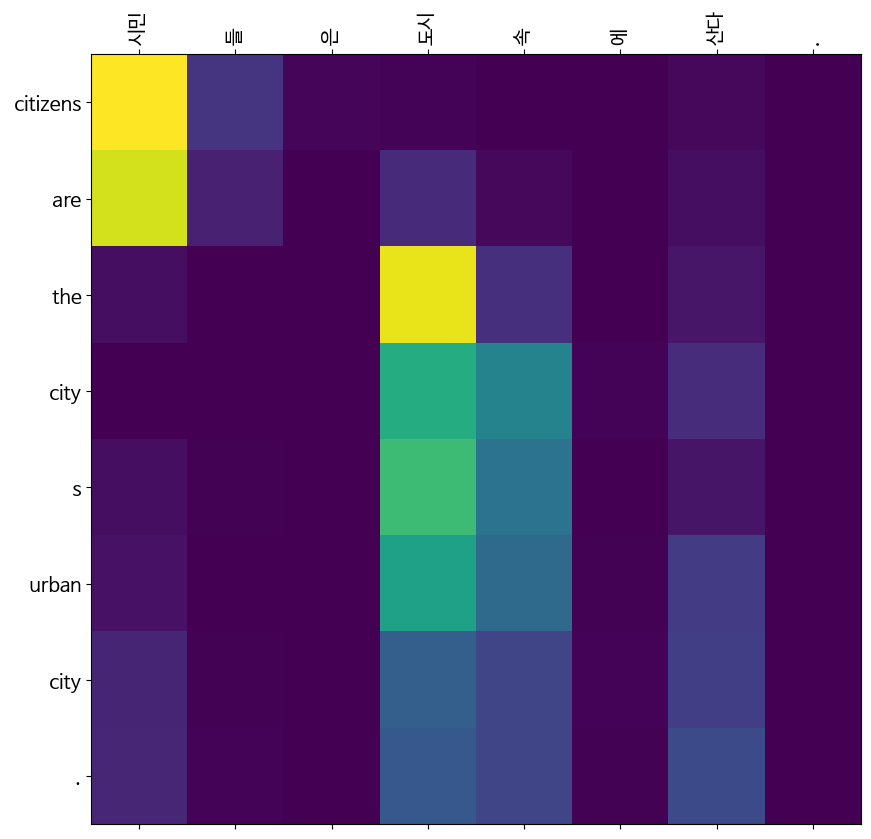

--------------------------------------------------
Input: 커피는 필요 없다.
Predicted translation: ['▁coffee', '▁coffee', '▁coffee', '▁coffee', '▁coffee', '▁coffee', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


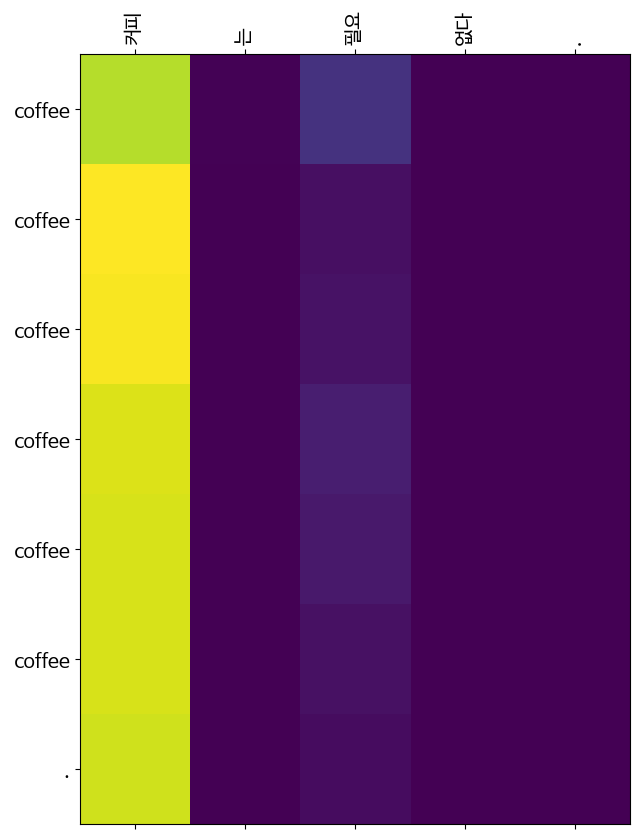

--------------------------------------------------
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ['▁the', '▁death', '▁toll', '▁occurred', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


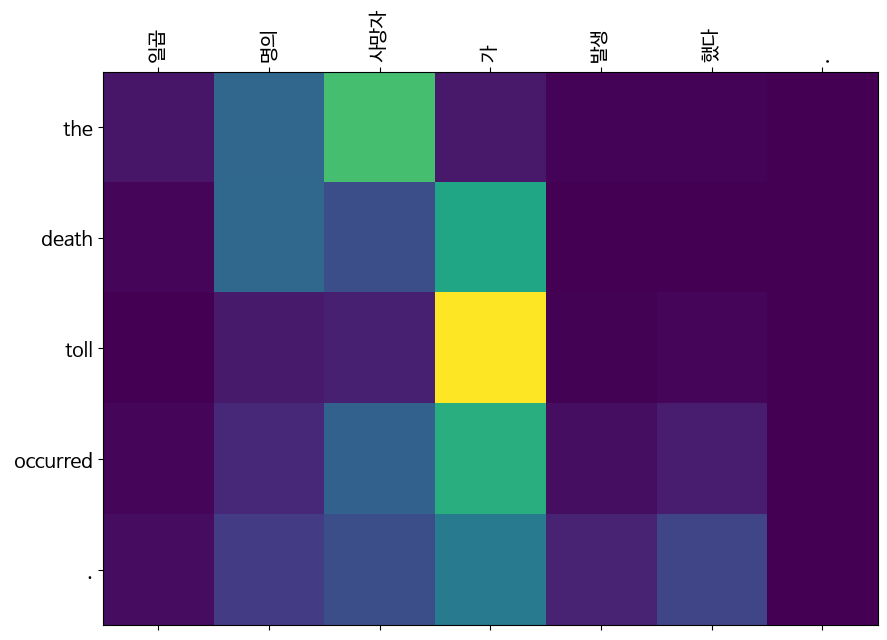

--------------------------------------------------

=== 튜닝 모델 검증 데이터 번역 샘플 ===

🗣️ 한국어 (Input)    : 민 왕후 는 왕 과 왕비 의 개인 적 인 거처 인 건청궁 에서 그녀 를 닮은 두 명의 다른 여인 들 과 함께 살해 되었다 .
✅ 실제 (Actual)   : min was slain in geoncheonggung residence , the king and queen s private quarters , along with two other women resembling her .
🤖 예측 (Predicted): ▁the▁royalty▁is▁a▁former▁member▁of▁the▁royal▁society▁,▁and▁two▁other▁people▁who▁died▁in▁a▁palace▁in▁the▁palace▁of▁princess▁royal▁palaces▁.
------------------------------------------------------------
🗣️ 한국어 (Input)    : 그때 , 김정일 주석 은 서울 답방 을 약속 했으나 아직 그 약속 은 지켜지지 않고 있다 .
✅ 실제 (Actual)   : at that time , kim jong il promised to make a return visit to seoul , but he has yet to keep that promise .
🤖 예측 (Predicted): ▁he▁s▁been▁a▁seoul▁metropolitan▁government▁office▁,▁but▁he▁promised▁to▁take▁office▁in▁the▁promise▁.
------------------------------------------------------------
🗣️ 한국어 (Input)    : 루치아노 스 팔레 티 AS 로마 감독 은 미드필더 들 인 다니 엘레 데로시 , 시모네 페로타 그리고 포워드 인 미르코 부치니

In [72]:
print("=== 하이퍼파라미터 튜닝 모델(Tuned Model) 번역 및 Attention Map 테스트 ===\n")

# 1. 고정된 테스트 문장 번역 및 시각화
for sentence in test_sentences:
    ko_en_translate(sentence, tuned_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)
    print("-" * 50)

# 2. 검증 데이터(Validation Set) 무작위 샘플 번역 비교
print("\n=== 튜닝 모델 검증 데이터 번역 샘플 ===\n")
samples = full_valid_data.sample(5) # 전체 데이터셋의 Validation 셋에서 추출

for idx, row in samples.iterrows():
    ko_text = row['ko']
    en_text = row['en']

    # evaluate 함수를 통해 예측 결과만 가져오기
    result, _, _ = ko_en_evaluate(ko_text, tuned_model, ko_tokenizer, en_tokenizer, max_len=MAX_LEN)

    # SentencePiece의 띄어쓰기 특수기호( )를 일반 공백으로 변환하여 문장 복원
    pred_sentence = "".join(result).replace(' ', ' ').strip()

    print(f"🗣️ 한국어 (Input)    : {ko_text}")
    print(f"✅ 실제 (Actual)   : {en_text}")
    print(f"🤖 예측 (Predicted): {pred_sentence}")
    print("-" * 60)

## 결론
### 모델 구조의 한계 (GRU vs Transformer): 현재 저희가 실습한 모델은 RNN 계열인 GRU 기반의 Seq2Seq + Attention 모델입니다. 이 구조는 문장이 길어질수록 성능이 떨어지는 한계가 있습니다. 현대의 고성능 번역기(구글 번역, DeepL, ChatGPT 등)는 모두 Transformer라는 더 발전된 구조를 사용합니다.


### 데이터의 양과 질: 실습에 사용한 데이터는 약 7.8만 개입니다. 실제 상용 번역기는 수백만에서 수천만 개의 고품질 병렬 문장 쌍(Parallel Corpus)을 학습합니다.


### 사전 학습(Pre-training)의 부재: 단어를 벡터로 바꿀 때(Embedding) 아무 지식이 없는 상태에서 처음부터 학습했습니다. BERT, Word2Vec처럼 이미 방대한 지식을 가진 모델을 활용하면 성능이 훨씬 좋아집니다.

### [추가 실습] OpenSubtitles 데이터셋 다운로드 및 로드
영화 및 TV 프로그램 자막으로 구성된 대규모 일상 대화 데이터셋입니다.

In [76]:
import os
import urllib.request
import zipfile
import pandas as pd

# 다운로드 경로 설정
opus_dir = "/content/opensubtitles"
os.makedirs(opus_dir, exist_ok=True)
zip_path = os.path.join(opus_dir, "en-ko.txt.zip")

# 1. 데이터 다운로드 (OPUS 백엔드 스토리지 직접 접근)
url = "https://object.pouta.csc.fi/OPUS-OpenSubtitles/v2018/moses/en-ko.txt.zip"
if not os.path.exists(zip_path):
    print("OpenSubtitles 데이터 다운로드 중... (시간이 다소 소요될 수 있습니다)")
    # 보안 연결 및 다운로드를 위해 User-Agent 헤더 추가
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(zip_path, 'wb') as out_file:
        out_file.write(response.read())
    print("다운로드 완료!")
else:
    print("이미 데이터가 존재합니다.")

# 2. 압축 해제
print("압축 해제 중...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(opus_dir)
print("압축 해제 완료!")

# 3. 데이터 로드 (Moses 포맷)
ko_path = os.path.join(opus_dir, "OpenSubtitles.en-ko.ko")
en_path = os.path.join(opus_dir, "OpenSubtitles.en-ko.en")

print("데이터를 읽어오는 중...")
with open(ko_path, "r", encoding="utf-8") as f:
    ko_data_sub = f.read().splitlines()

with open(en_path, "r", encoding="utf-8") as f:
    en_data_sub = f.read().splitlines()

# 데이터프레임으로 변환 (길이가 다를 수 있으므로 최소 길이로 맞춤)
min_len = min(len(ko_data_sub), len(en_data_sub))
opus_df = pd.DataFrame({"ko": ko_data_sub[:min_len], "en": en_data_sub[:min_len]})

print(f"\nOpenSubtitles 총 데이터 개수: {len(opus_df):,}개")
display(opus_df.head(10))


이미 데이터가 존재합니다.
압축 해제 중...
압축 해제 완료!
데이터를 읽어오는 중...

OpenSubtitles 총 데이터 개수: 1,391,190개


,ko,en
0,"폭설이 내리고 우박, 진눈깨비가 퍼부어도 눈보라가 몰아쳐도 강풍이 불고 비바람이 휘...","Through the snow and sleet and hail, through t..."
1,우리의 한결같은 심부름꾼 황새 아저씨 가는 길을 그 누가 막으랴!,"ever faithful, ever true, nothing stops him, h..."
2,황새 아저씨를 기다리세요,Look out for Mr Stork That persevering chap
3,찾아와 선물을 주실 거예요,He'll come along and drop a bundle in your lap
4,가난하든 부자이든 상관이 없답니다,You may be poor or rich It doesn't matter which
5,백만장자도 하나 가난뱅이도 하나,"Millionaires, they get theirs like the butcher..."
6,황새 아저씨를 기다리세요,"So look out for Mr Stork and let me tell you, ..."
7,도망쳐도 소용없어요 반드시 찾아내니까요,Don't try to get away He'll find you in the end
8,세상 끝에 있어도 하늘 꼭대기에 있어도,He'll spot you out in China or he'll fly to Co...
9,황새 아저씨는 찾아간답니다,"So, you better look out for Mr Stork"


데이터가 굉장히 많으므로 (약 100만 개 이상), 이전 뉴스 말뭉치 전처리 과정(결측치 제거, 특수문자 정제, 형태소 분석)을 동일하게 거친 후 모델 학습에 활용하시면 됩니다.

In [77]:
print(f"정제 전 데이터 개수: {len(opus_df):,}개")

# 중복 문장 쌍 제거
opus_df.drop_duplicates(inplace=True)

# 결측치 제거
opus_df.dropna(inplace=True)

print(f"정제 후 데이터 개수: {len(opus_df):,}개")
display(opus_df.head(10))

정제 전 데이터 개수: 1,391,190개
정제 후 데이터 개수: 1,379,885개


,ko,en
0,"폭설이 내리고 우박, 진눈깨비가 퍼부어도 눈보라가 몰아쳐도 강풍이 불고 비바람이 휘...","Through the snow and sleet and hail, through t..."
1,우리의 한결같은 심부름꾼 황새 아저씨 가는 길을 그 누가 막으랴!,"ever faithful, ever true, nothing stops him, h..."
2,황새 아저씨를 기다리세요,Look out for Mr Stork That persevering chap
3,찾아와 선물을 주실 거예요,He'll come along and drop a bundle in your lap
4,가난하든 부자이든 상관이 없답니다,You may be poor or rich It doesn't matter which
5,백만장자도 하나 가난뱅이도 하나,"Millionaires, they get theirs like the butcher..."
6,황새 아저씨를 기다리세요,"So look out for Mr Stork and let me tell you, ..."
7,도망쳐도 소용없어요 반드시 찾아내니까요,Don't try to get away He'll find you in the end
8,세상 끝에 있어도 하늘 꼭대기에 있어도,He'll spot you out in China or he'll fly to Co...
9,황새 아저씨는 찾아간답니다,"So, you better look out for Mr Stork"


In [78]:
# 빠른 학습 및 전처리를 위해 3만 개만 샘플링합니다.
# 전체 데이터를 사용하려면 이 줄을 주석 처리하고 opus_sample_df = opus_df.copy() 를 사용하세요.
opus_sample_df = opus_df.sample(30000, random_state=42).reset_index(drop=True)

print("OpenSubtitles 데이터 샘플(3만 개) 전처리 진행 중... (시간이 조금 걸릴 수 있습니다)")

# 이미 정의된 전처리 함수(Okt 형태소 분석기 포함)를 적용합니다.
opus_sample_df['ko'] = opus_sample_df['ko'].apply(preprocess_korean)
opus_sample_df['en'] = opus_sample_df['en'].apply(preprocess_english)

print("전처리 완료!")
display(opus_sample_df.head())


OpenSubtitles 데이터 샘플(3만 개) 전처리 진행 중... (시간이 조금 걸릴 수 있습니다)
전처리 완료!


,ko,en
0,잠시 걱정 했어요 .,i was afraid you and i weren t gonna have anyt...
1,올라가지 말 라고 했어요,yeah !
2,샬롯 한테 무슨 . . . 샬롯 의 집 주소 가 필요합니다,"patrick could be . . . oh , god !"
3,가끔 난 하나 쯤 있는게 좋다고 생각 해 .,really ?
4,저편 에서 봅시다,two . . .


In [79]:
import sentencepiece as spm
import torch
from torch.utils.data import DataLoader

# 1. 텍스트 파일로 저장 (OpenSubtitles SentencePiece 학습용)
opus_sample_df["ko"].to_csv("opus_ko_corpus.txt", index=False, header=False, encoding="utf-8")
opus_sample_df["en"].to_csv("opus_en_corpus.txt", index=False, header=False, encoding="utf-8")

# 2. SentencePiece 모델 학습
vocab_size = 5000
pad_id, bos_id, eos_id, unk_id = 0, 1, 2, 3

print("OpenSubtitles 한국어 SentencePiece 모델 학습 중...")
spm.SentencePieceTrainer.train(
    input="opus_ko_corpus.txt",
    model_prefix="opus_ko_spm",
    vocab_size=vocab_size,
    pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id
)

print("OpenSubtitles 영어 SentencePiece 모델 학습 중...")
spm.SentencePieceTrainer.train(
    input="opus_en_corpus.txt",
    model_prefix="opus_en_spm",
    vocab_size=vocab_size,
    pad_id=pad_id, bos_id=bos_id, eos_id=eos_id, unk_id=unk_id
)

# 3. 토크나이저 로드
opus_ko_tokenizer = spm.SentencePieceProcessor()
opus_ko_tokenizer.load("opus_ko_spm.model")

opus_en_tokenizer = spm.SentencePieceProcessor()
opus_en_tokenizer.load("opus_en_spm.model")

# 4. Train / Validation 분리 및 DataLoader 생성
train_ratio = 0.8
opus_train_data = opus_sample_df.sample(frac=train_ratio, random_state=42)
opus_valid_data = opus_sample_df.drop(opus_train_data.index)

opus_train_data.reset_index(drop=True, inplace=True)
opus_valid_data.reset_index(drop=True, inplace=True)

MAX_LEN = 40
BATCH_SIZE = 64

# 기존에 정의해둔 KoEnTranslationDataset 클래스를 재사용합니다.
opus_train_dataset = KoEnTranslationDataset(opus_train_data, opus_ko_tokenizer, opus_en_tokenizer, max_len=MAX_LEN)
opus_valid_dataset = KoEnTranslationDataset(opus_valid_data, opus_ko_tokenizer, opus_en_tokenizer, max_len=MAX_LEN)

opus_train_loader = DataLoader(opus_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
opus_valid_loader = DataLoader(opus_valid_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nOpenSubtitles 훈련 데이터 개수: {len(opus_train_dataset)}")
print(f"OpenSubtitles 검증 데이터 개수: {len(opus_valid_dataset)}")
print("DataLoader 준비 완료!")

OpenSubtitles 한국어 SentencePiece 모델 학습 중...
OpenSubtitles 영어 SentencePiece 모델 학습 중...

OpenSubtitles 훈련 데이터 개수: 24000
OpenSubtitles 검증 데이터 개수: 6000
DataLoader 준비 완료!


### OpenSubtitles 데이터셋으로 모델 학습 및 평가하기

OpenSubtitles 데이터셋으로 번역 모델 학습을 시작합니다! (Bi-directional, Early Stopping)


Epoch 1: 100%|██████████| 375/375 [00:14<00:00, 26.44it/s, loss=4.62]


Epoch 1/15, Train Loss: 4.9519, Validation Loss: 4.5808


Epoch 2: 100%|██████████| 375/375 [00:13<00:00, 27.61it/s, loss=4.37]


Epoch 2/15, Train Loss: 4.4309, Validation Loss: 4.4025


...

Epoch 6/15, Train Loss: 3.7156, Validation Loss: 4.3434
Early Stopping Patience: 1/3


Epoch 7: 100%|██████████| 375/375 [00:13<00:00, 27.79it/s, loss=3.71]


Epoch 7/15, Train Loss: 3.5559, Validation Loss: 4.3854
Early Stopping Patience: 2/3


Epoch 8: 100%|██████████| 375/375 [00:13<00:00, 27.79it/s, loss=3.39]


Epoch 8/15, Train Loss: 3.4049, Validation Loss: 4.4204
Early Stopping Patience: 3/3
Validation Loss가 개선되지 않아 조기 종료(Early Stopping)합니다!

최고 성능의 모델 가중치를 불러옵니다.


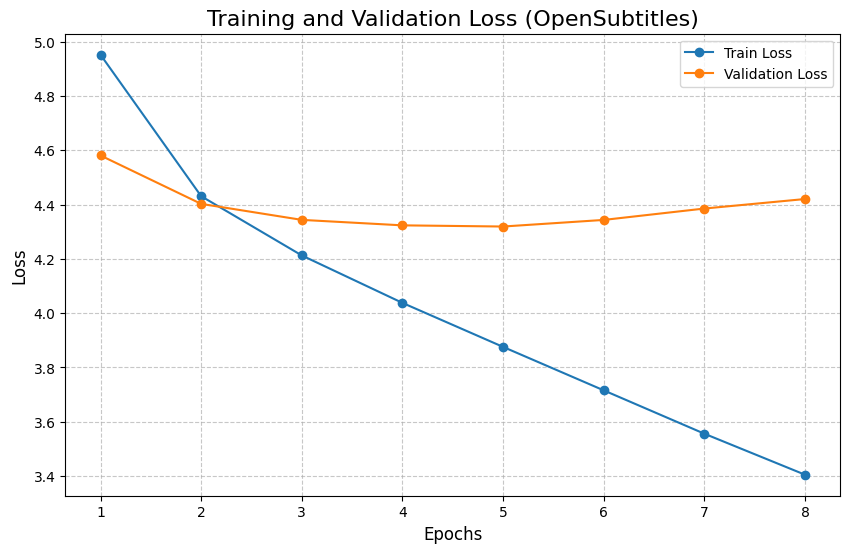

In [80]:
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. 하이퍼파라미터 설정
opus_vocab_size = 5000
emb_dim = 256
hid_dim = 512
dropout_rate = 0.5
EPOCHS = 15
patience = 3

# 2. 모델 초기화 (이전에 성능이 좋았던 양방향 BiEncoder 사용)
opus_encoder = BiEncoder(opus_vocab_size, emb_dim, hid_dim, dropout_p=dropout_rate).to(device)
opus_attention = BahdanauAttention(hid_dim).to(device)
opus_decoder = Decoder(opus_vocab_size, emb_dim, hid_dim, opus_attention, dropout_p=dropout_rate).to(device)
opus_model = Seq2SeqAttention(opus_encoder, opus_decoder, device).to(device)

# 3. Optimizer 및 Loss 설정
opus_optimizer = optim.Adam(opus_model.parameters(), lr=5e-4)
opus_criterion = nn.CrossEntropyLoss(ignore_index=0) # 패딩(0)은 무시

# 4. 학습 진행 (Early Stopping 적용)
opus_train_history = []
opus_valid_history = []
best_valid_loss = float('inf')
patience_counter = 0

print("OpenSubtitles 데이터셋으로 번역 모델 학습을 시작합니다! (Bi-directional, Early Stopping)")
for epoch in range(EPOCHS):
    train_loss = train_step(opus_model, opus_train_loader, opus_optimizer, opus_criterion, epoch)
    valid_loss = eval_step(opus_model, opus_valid_loader, opus_optimizer, opus_criterion)

    opus_train_history.append(train_loss)
    opus_valid_history.append(valid_loss)

    print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}')

    # Early Stopping 로직
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        patience_counter = 0
        torch.save(opus_model.state_dict(), 'best_opus_model.pt')
    else:
        patience_counter += 1
        print(f'Early Stopping Patience: {patience_counter}/{patience}')
        if patience_counter >= patience:
            print("Validation Loss가 개선되지 않아 조기 종료(Early Stopping)합니다!")
            break

# 최고 성능 모델 로드
print("\n최고 성능의 모델 가중치를 불러옵니다.")
opus_model.load_state_dict(torch.load('best_opus_model.pt', weights_only=True))

# === Train / Validation Loss 시각화 ===
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(opus_train_history) + 1), opus_train_history, label='Train Loss', marker='o')
plt.plot(range(1, len(opus_valid_history) + 1), opus_valid_history, label='Validation Loss', marker='o')

plt.title('Training and Validation Loss (OpenSubtitles)', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

=== OpenSubtitles 모델 번역 및 Attention Map 테스트 ===

Input: 잠시 걱정 했어요.
Predicted translation: ['▁i', '▁m', '▁sorry', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


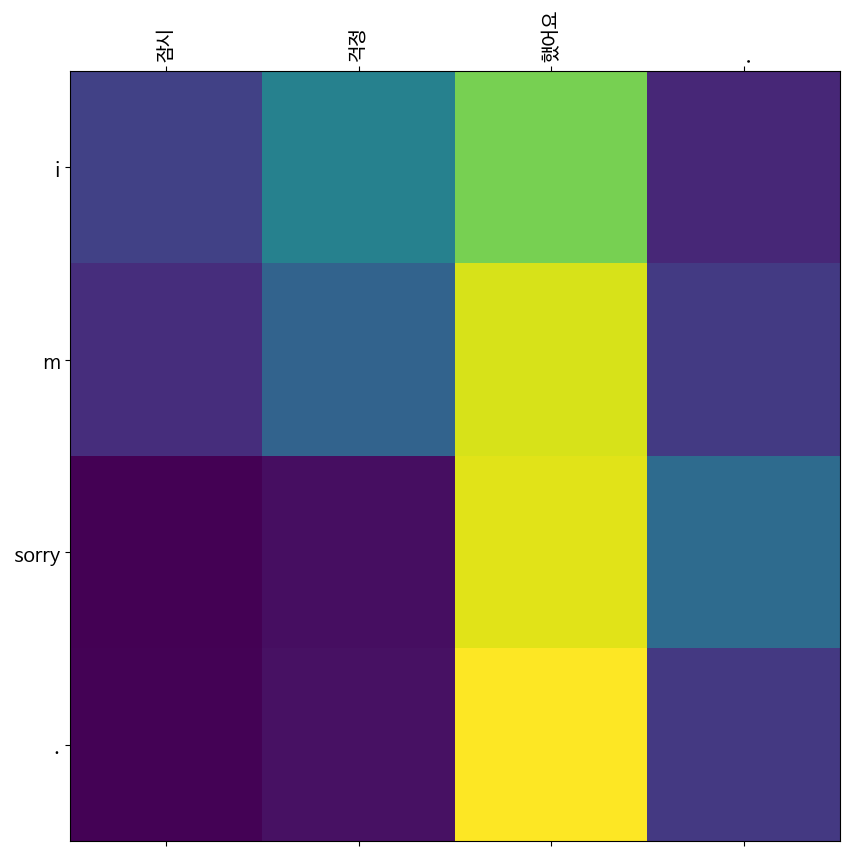

--------------------------------------------------
Input: 저편에서 봅시다.
Predicted translation: ['▁i', '▁m', '▁sorry', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


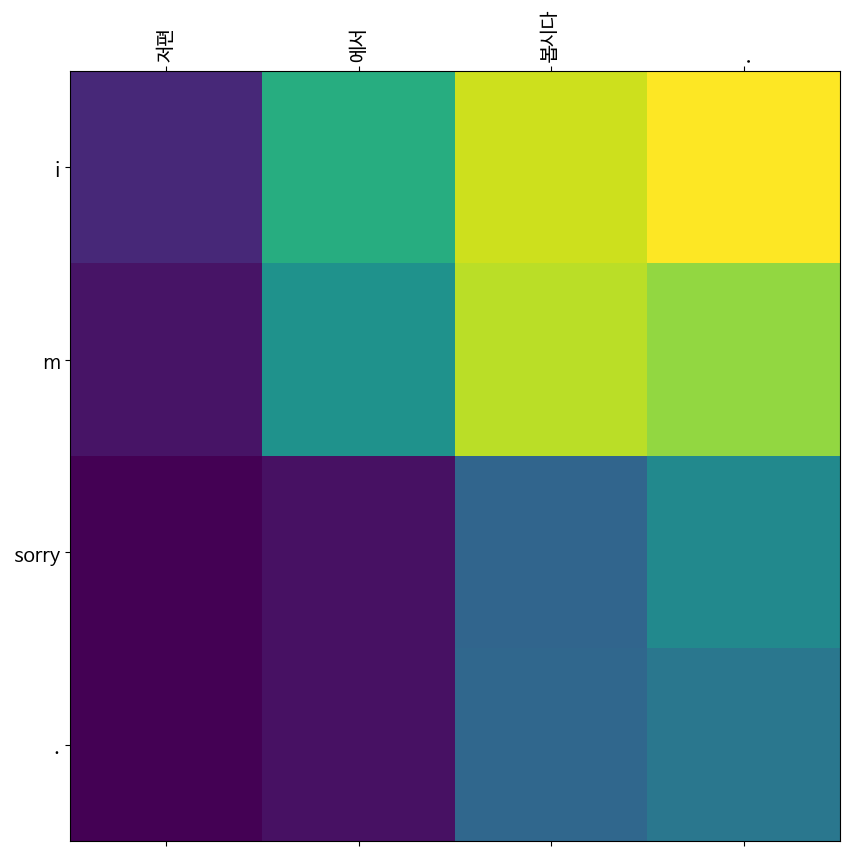

--------------------------------------------------
Input: 정말 좋은 날씨네요.
Predicted translation: ['▁i', '▁m', '▁sorry', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


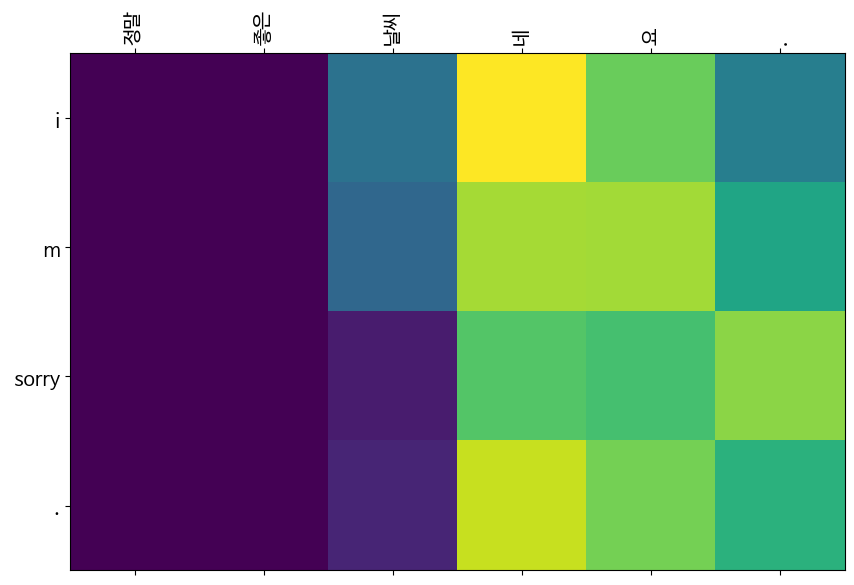

--------------------------------------------------
Input: 어디로 가는 길인가요?
Predicted translation: ['▁i', '▁m', '▁not', '▁sure', '▁you', '▁re', '▁not', '▁gonna', '▁be', '▁a', '▁long', '▁time', '▁ago', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


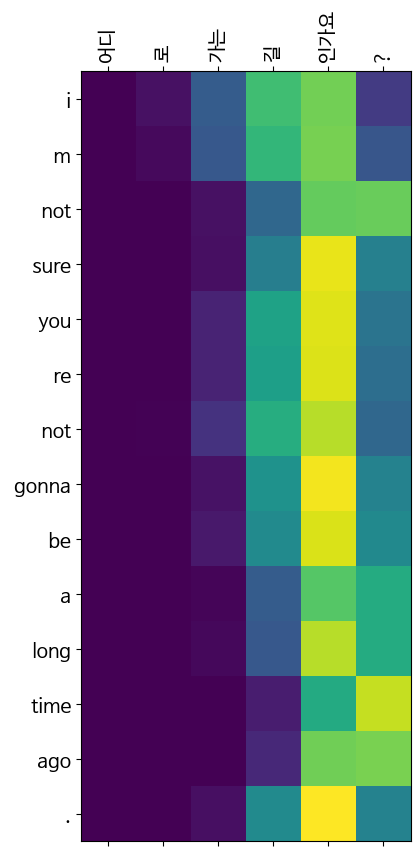

--------------------------------------------------

=== OpenSubtitles 검증 데이터 번역 샘플 ===

🗣️ 한국어 (Input)    : 좋아 , 마음대로 해
✅ 실제 (Actual)   : it s a drastic solution that s only considered when all other options have failed , because once a surgeon makes that cut , there s no going back .
🤖 예측 (Predicted): ▁i▁m▁sorry▁.
------------------------------------------------------------
🗣️ 한국어 (Input)    : 내 가 월세 를 내주는데 그걸 모르겠니
✅ 실제 (Actual)   : and we re very grateful for it .
🤖 예측 (Predicted): ▁i▁m▁gonna▁need▁to▁get▁to▁the▁bathroom▁.
------------------------------------------------------------
🗣️ 한국어 (Input)    : Thank you
✅ 실제 (Actual)   : heil hitler .
🤖 예측 (Predicted): ▁i▁m▁sorry▁.
------------------------------------------------------------
🗣️ 한국어 (Input)    : 왜 이런 얘기 안 해줬어 ?
✅ 실제 (Actual)   : i don t know , i guess i was just afraid you d be weirded out or people would label me a slut , or i don t know .
🤖 예측 (Predicted): ▁i▁m▁sorry▁.
--------------------------------------------------------

In [81]:
print("=== OpenSubtitles 모델 번역 및 Attention Map 테스트 ===\n")

# 일상 대화 위주의 테스트 문장
test_sentences_opus = [
    "잠시 걱정 했어요.",
    "저편에서 봅시다.",
    "정말 좋은 날씨네요.",
    "어디로 가는 길인가요?"
]

for sentence in test_sentences_opus:
    ko_en_translate(sentence, opus_model, opus_ko_tokenizer, opus_en_tokenizer, max_len=MAX_LEN)
    print("-" * 50)

# 검증 데이터(Validation Set) 무작위 샘플 번역 비교
print("\n=== OpenSubtitles 검증 데이터 번역 샘플 ===\n")
samples = opus_valid_data.sample(5)

for idx, row in samples.iterrows():
    ko_text = row['ko']
    en_text = row['en']

    result, _, _ = ko_en_evaluate(ko_text, opus_model, opus_ko_tokenizer, opus_en_tokenizer, max_len=MAX_LEN)
    pred_sentence = "".join(result).replace(' ', ' ').strip()

    print(f"🗣️ 한국어 (Input)    : {ko_text}")
    print(f"✅ 실제 (Actual)   : {en_text}")
    print(f"🤖 예측 (Predicted): {pred_sentence}")
    print("-" * 60)

=== OpenSubtitles 모델에 이전 뉴스 문장(test_sentences) 테스트 ===

Input: 오바마는 미국 대통령이다.
Predicted translation: ['▁the', '▁only', '▁thing', '▁is', '▁the', '▁most', '▁of', '▁the', '▁most', '▁of', '▁the', '▁most', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


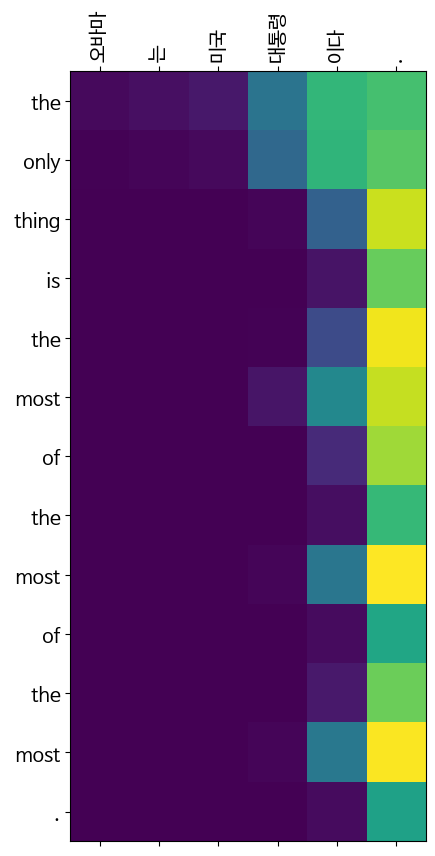

--------------------------------------------------
Input: 시민들은 도시 속에 산다.
Predicted translation: ['▁they', '▁re', '▁not', '▁gonna', '▁be', '▁a', '▁good', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


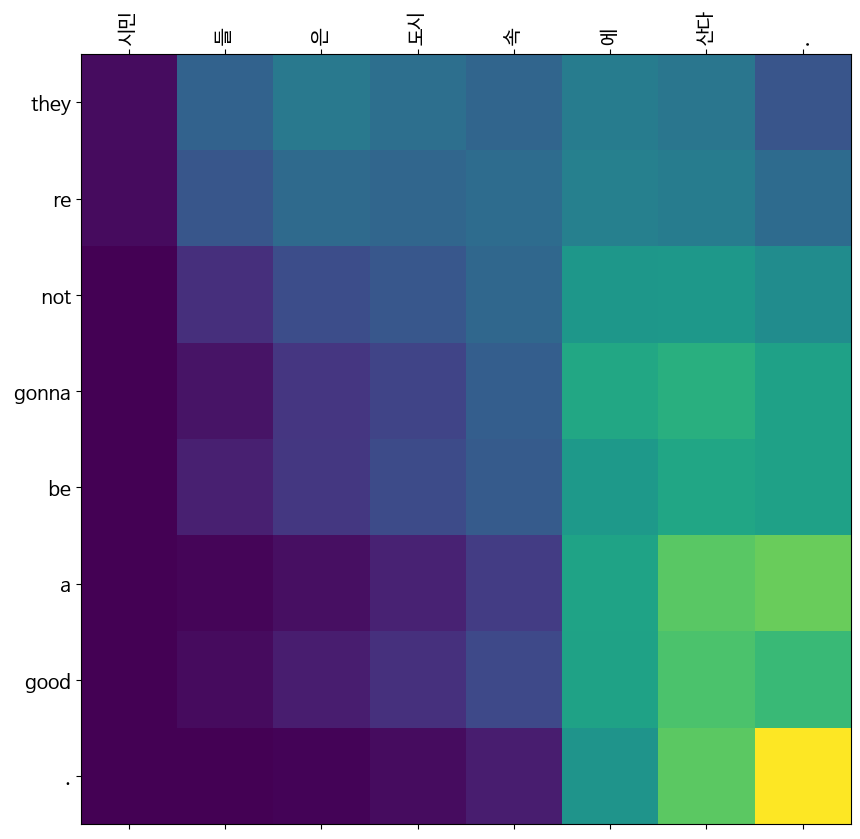

--------------------------------------------------
Input: 커피는 필요 없다.
Predicted translation: ['▁i', '▁m', '▁sorry', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


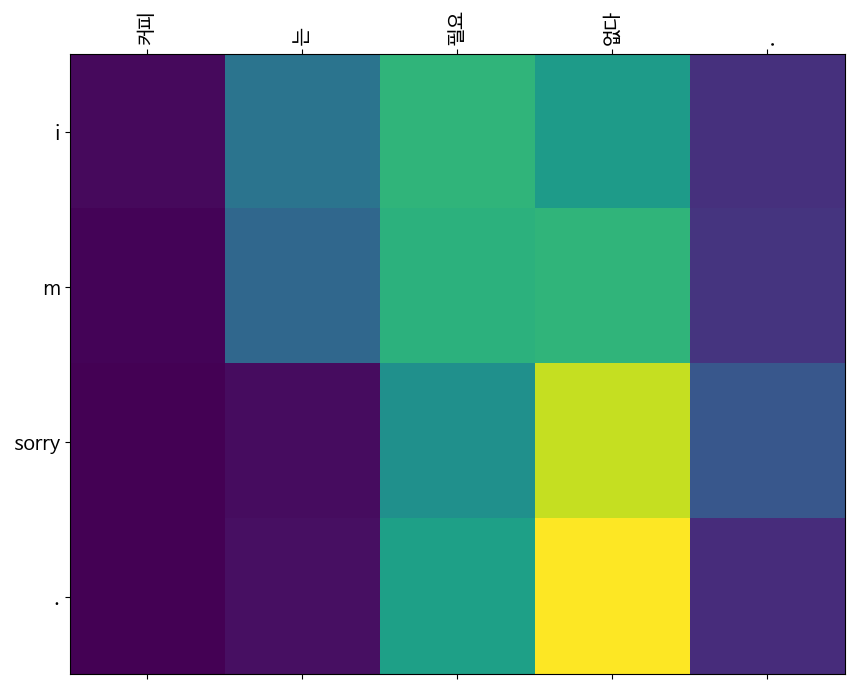

--------------------------------------------------
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: ['▁i', '▁m', '▁sorry', '▁.']


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


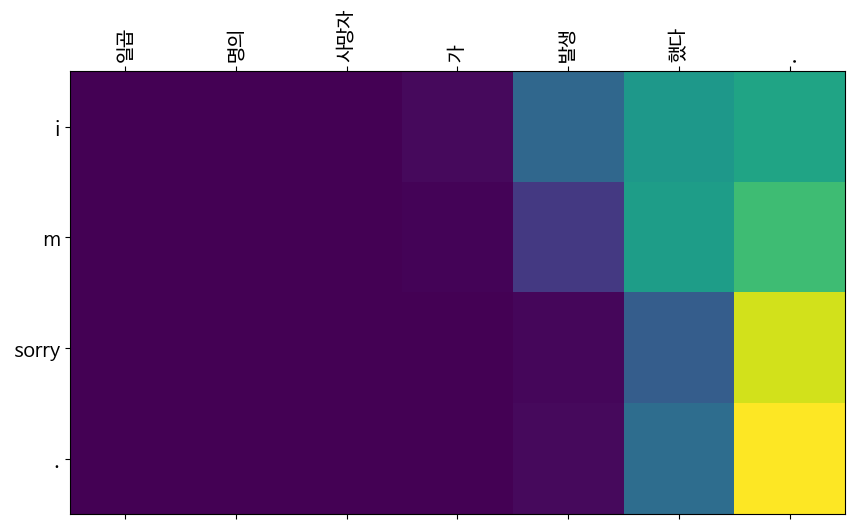

--------------------------------------------------


In [82]:
print("=== OpenSubtitles 모델에 이전 뉴스 문장(test_sentences) 테스트 ===\n")

for sentence in test_sentences:
    ko_en_translate(sentence, opus_model, opus_ko_tokenizer, opus_en_tokenizer, max_len=MAX_LEN)
    print("-" * 50)


### [추가 실험] 사전 학습된 거대 모델(Pre-trained Models) 성능 확인하기

Hugging Face에서 제공하는 SOTA(State-of-the-Art) 번역 모델들을 불러와서 성능을 테스트해 봅니다. 거대한 Transformer 아키텍처와 압도적인 양의 데이터로 학습된 모델들의 위력을 확인해 보세요!

In [83]:
!pip install -q transformers
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_sentences = [
    "오바마는 미국 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

In [84]:
print("=== 1. Helsinki-NLP/opus-mt-ko-en 모델 로드 및 테스트 ===\n")

model_name_helsinki = "Helsinki-NLP/opus-mt-ko-en"
tokenizer_helsinki = AutoTokenizer.from_pretrained(model_name_helsinki)
model_helsinki = AutoModelForSeq2SeqLM.from_pretrained(model_name_helsinki).to(device)

print("[Helsinki-NLP 번역 결과]")
for sentence in test_sentences:
    inputs = tokenizer_helsinki(sentence, return_tensors="pt").to(device)
    translated_tokens = model_helsinki.generate(**inputs, max_length=50)
    translated_text = tokenizer_helsinki.batch_decode(translated_tokens, skip_special_tokens=True)[0]

    print(f"🗣️ 한국어: {sentence}")
    print(f"🤖 영어  : {translated_text}")
    print("-" * 50)

=== 1. Helsinki-NLP/opus-mt-ko-en 모델 로드 및 테스트 ===



config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/842k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/813k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  312MB            

model.safetensors: downloading bytes:           |  0.00B            

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

[Helsinki-NLP 번역 결과]
🗣️ 한국어: 오바마는 미국 대통령이다.
🤖 영어  : Obama is president of the United States.
--------------------------------------------------
🗣️ 한국어: 시민들은 도시 속에 산다.
🤖 영어  : Citizens live in cities.
--------------------------------------------------
🗣️ 한국어: 커피는 필요 없다.
🤖 영어  : I don't need coffee.
--------------------------------------------------
🗣️ 한국어: 일곱 명의 사망자가 발생했다.
🤖 영어  : Seven people were killed.
--------------------------------------------------


In [88]:
print("=== 2. facebook/nllb-200-distilled-600M 모델 로드 및 테스트 ===\n")

# NLLB 모델은 200개 언어를 지원하며, 입력 언어와 출력 언어 코드를 명확히 지정해주어야 합니다.
# 한국어: kor_Hang, 영어: eng_Latn
model_name_nllb = "facebook/nllb-200-distilled-600M"
tokenizer_nllb = AutoTokenizer.from_pretrained(model_name_nllb, src_lang="kor_Hang", use_fast=False)
model_nllb = AutoModelForSeq2SeqLM.from_pretrained(model_name_nllb).to(device)

print("[NLLB-200 번역 결과]")
for sentence in test_sentences:
    inputs = tokenizer_nllb(sentence, return_tensors="pt").to(device)
    # 영어를 타겟 언어로 설정 (Forced BOS Token)
    # NLLB 토크나이저의 경우 'lang_code_to_id' 속성이 없을 수 있으므로,
    # 'convert_tokens_to_ids'를 사용하여 언어 토큰 ID를 얻는 것이 더 안정적입니다.
    eng_lang_id = tokenizer_nllb.convert_tokens_to_ids("__eng_Latn__")
    translated_tokens = model_nllb.generate(**inputs, forced_bos_token_id=eng_lang_id, max_length=50)
    translated_text = tokenizer_nllb.batch_decode(translated_tokens, skip_special_tokens=True)[0]

    print(f"🗣️ 한국어: {sentence}")
    print(f"🤖 영어  : {translated_text}")
    print("-" * 50)

=== 2. facebook/nllb-200-distilled-600M 모델 로드 및 테스트 ===



Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

[NLLB-200 번역 결과]
🗣️ 한국어: 오바마는 미국 대통령이다.
🤖 영어  : Obama is President of the United States.
--------------------------------------------------
🗣️ 한국어: 시민들은 도시 속에 산다.
🤖 영어  : Citizens live in cities.
--------------------------------------------------
🗣️ 한국어: 커피는 필요 없다.
🤖 영어  : ️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️
--------------------------------------------------
🗣️ 한국어: 일곱 명의 사망자가 발생했다.
🤖 영어  : 
--------------------------------------------------


Matplotlib font set to: NanumBarunGothic


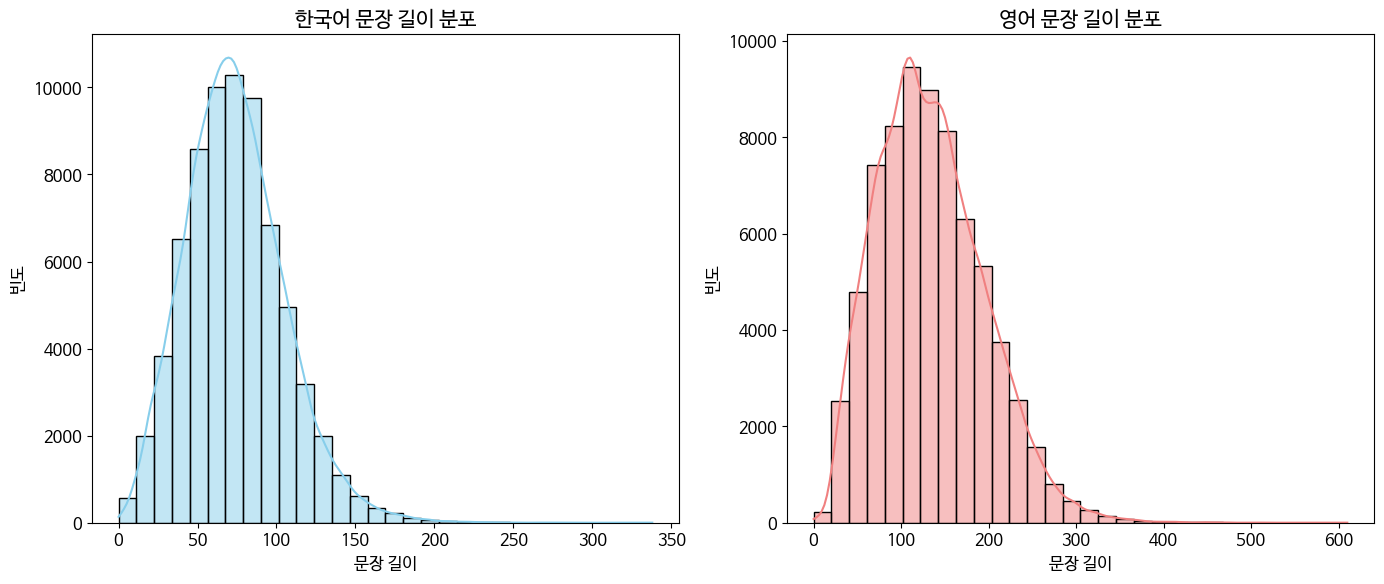

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os

# NanumBarunGothic 폰트 경로
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"

# 폰트 파일이 존재하는지 확인 (선택 사항, 하지만 유용)
if not os.path.exists(fontpath):
    print(f"Warning: Font file not found at {fontpath}. Korean text might not display correctly.")
else:
    try:
        # 폰트를 Matplotlib의 폰트 관리자에 추가
        fm.fontManager.addfont(fontpath)

        prop = fm.FontProperties(fname=fontpath)
        font_name = prop.get_name()

        # Matplotlib의 기본 폰트 설정을 NanumBarunGothic으로 명시적으로 재설정합니다.
        plt.rcParams['font.family'] = font_name
        plt.rcParams['font.sans-serif'] = [font_name] + plt.rcParams['font.sans-serif'] # NanumBarunGothic을 최우선으로 설정
        plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 문제 해결
        plt.rcParams['font.size'] = 12 # 기본 폰트 크기 설정

        print(f"Matplotlib font set to: {font_name}")

    except Exception as e:
        print(f"Error setting font: {e}")
        print("Continuing with default fonts, Korean text might not display correctly.")


# 한국어 문장 길이 계산
ko_lengths = full_train_data['ko'].apply(len)

# 영어 문장 길이 계산
en_lengths = full_train_data['en'].apply(len)

plt.figure(figsize=(14, 6))

# 한국어 문장 길이 분포
plt.subplot(1, 2, 1)
sns.histplot(ko_lengths, bins=30, kde=True, color='skyblue')
plt.title('한국어 문장 길이 분포', fontsize=15)
plt.xlabel('문장 길이', fontsize=12)
plt.ylabel('빈도', fontsize=12)

# 영어 문장 길이 분포
plt.subplot(1, 2, 2)
sns.histplot(en_lengths, bins=30, kde=True, color='lightcoral')
plt.title('영어 문장 길이 분포', fontsize=15)
plt.xlabel('문장 길이', fontsize=12)
plt.ylabel('빈도', fontsize=12)

plt.tight_layout()
plt.show()

In [90]:
print("\n=== 번역 학습 데이터 샘플 (full_train_data) ===\n")
display(full_train_data.head())


=== 번역 학습 데이터 샘플 (full_train_data) ===



,ko,en
0,Fight the Future 은 1998년 세상 에 공개 됐다 .,fight the future .
1,한편 스페인 은 북아일랜드 와의 경기 에서 쟈비 의 결승골 로 1 0 으로 승리 했다 .,"an unlikely victory in gran canaria , combined..."
2,Hugh Jackman Heartbroken over Wolverine Leak a...,and he says that could lead to implanting othe...
3,관계자 들 은 그 들 의 신변 을 보호 할 것 이며 이 것 은 국제 법 위반 이 아...,they are seeking protection and this is not a ...
4,"경찰 , 김선일 씨 사망 이후 이슬람 사원 주변 의 보안 강화 2005 . 08",police strengthened security around the islam ...


NLLB-200 모델의 번역 문제 재현 여부를 확인하기 위해 새로운 한국어 테스트 문장들을 사용해 보겠습니다.

In [89]:
print("=== NLLB-200 모델 새로운 테스트 문장 ===\n")

new_test_sentences = [
    "안녕하세요.",
    "오늘은 날씨가 좋네요.",
    "이것은 펜입니다.",
    "저는 학생입니다."
]

# NLLB 모델은 200개 언어를 지원하며, 입력 언어와 출력 언어 코드를 명확히 지정해주어야 합니다.
# 한국어: kor_Hang, 영어: eng_Latn
model_name_nllb = "facebook/nllb-200-distilled-600M"
tokenizer_nllb = AutoTokenizer.from_pretrained(model_name_nllb, src_lang="kor_Hang", use_fast=False)
model_nllb = AutoModelForSeq2SeqLM.from_pretrained(model_name_nllb).to(device)

print("[NLLB-200 번역 결과 (새로운 문장)]")
for sentence in new_test_sentences:
    inputs = tokenizer_nllb(sentence, return_tensors="pt").to(device)
    # 영어를 타겟 언어로 설정 (Forced BOS Token)
    # NLLB 토크나이저의 경우 'lang_code_to_id' 속성이 없을 수 있으므로,
    # 'convert_tokens_to_ids'를 사용하여 언어 토큰 ID를 얻는 것이 더 안정적입니다.
    eng_lang_id = tokenizer_nllb.convert_tokens_to_ids("__eng_Latn__")
    translated_tokens = model_nllb.generate(**inputs, forced_bos_token_id=eng_lang_id, max_length=50)
    translated_text = tokenizer_nllb.batch_decode(translated_tokens, skip_special_tokens=True)[0]

    print(f"🗣️ 한국어: {sentence}")
    print(f"🤖 영어  : {translated_text}")
    print("-" * 50)

=== NLLB-200 모델 새로운 테스트 문장 ===



Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

[NLLB-200 번역 결과 (새로운 문장)]
🗣️ 한국어: 안녕하세요.
🤖 영어  : Hello!
--------------------------------------------------
🗣️ 한국어: 오늘은 날씨가 좋네요.
🤖 영어  : ️️️️️️️️️️️️️️️️️️️️️️️️
--------------------------------------------------
🗣️ 한국어: 이것은 펜입니다.
🤖 영어  : ️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️️
--------------------------------------------------
🗣️ 한국어: 저는 학생입니다.
🤖 영어  : I am a student.
--------------------------------------------------
